# Horse Colic: анализ качества данных

### EDA, поиск аномалий и обоснованная импутация пропусков

> **Portfolio edition.** Исходный принятый notebook сохранён отдельно. В портфолио-версии добавлены навигация, визуальный аудит, проверки качества и явное правило обработки ничьей при вычислении моды.

| Наблюдения | Выбранные признаки | Исходные пропуски | Строки с IQR-выбросами | Пропуски после обработки |
|---:|---:|---:|---:|---:|
| 300 | 8 | 255 | 33 | **0** |

**Стек:** Python · pandas · NumPy · SciPy · Matplotlib  
**Тип работы:** exploratory data analysis · data quality · missing-value imputation


## Навигация

1. [Аналитическая постановка](#аналитическая-постановка)
2. [Загрузка данных](#задача-1-загрузка-данных)
3. [Первичное изучение](#задача-2-первичное-изучение-данных)
4. [Анализ категориальных признаков](#21-анализ-категориальных-признаков)
5. [Работа с пропусками](#задача-3-работа-с-пропусками)
6. [Итоговый аудит](#итоговый-аудит-качества)
7. [Ограничения](#ограничения-и-границы-применения)


## О данных

Набор **Horse Colic** опубликован в UCI Machine Learning Repository. Исходные данные содержат категориальные, целочисленные и непрерывные клинические признаки с пропущенными значениями. В данном проекте анализируются 300 наблюдений обучающей части и 8 выбранных признаков.

**Источник:** McLeish, M. & Cecile, M. (1989). *Horse Colic* [Dataset]. UCI Machine Learning Repository. DOI: [10.24432/C58W23](https://doi.org/10.24432/C58W23).


## Аналитическая постановка

Исследуется набор данных `horse_data.csv` о состоянии лошадей с кишечными коликами. Цель — изучить структуру данных, найти статистические выбросы и обоснованно заполнить пропуски в восьми выбранных признаках.


### Задача 1. Загрузка данных

Изучить описание столбцов в `horse_data.names.txt`, загрузить данные и оставить восемь признаков: `surgery`, `age`, `rectal_temperature`, `pulse`, `respiratory_rate`, `temperature_of_extremities`, `pain`, `outcome`.


In [1]:
import pandas as pd
import numpy as np


In [2]:
from pathlib import Path

# Поиск датасета в структуре GitHub-проекта или в Google Colab
_data_candidates = [
    Path('data/horse_data.csv'),
    Path('horse_data.csv'),
    Path('/content/horse_data.csv'),
]
DATA_PATH = next((path for path in _data_candidates if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        'Файл horse_data.csv не найден. '
        'Запустите notebook из корня проекта или загрузите файл в /content/.'
    )

print(f'Источник данных: {DATA_PATH}')


Источник данных: data/horse_data.csv


In [3]:
horse_data_all = pd.read_csv(DATA_PATH, header=None)

#столбцы не имеют заголовков, поэтому мы их сначала просто нумеруем


In [4]:
horse_data_all


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,2,1,530101,38.50,66,28,3,3,?,2,5,4,4,?,?,?,3,5,45.00,8.40,?,?,2,2,11300,0,0,2
1,1,1,534817,39.2,88,20,?,?,4,1,3,4,2,?,?,?,4,2,50,85,2,2,3,2,2208,0,0,2
2,2,1,530334,38.30,40,24,1,1,3,1,3,3,1,?,?,?,1,1,33.00,6.70,?,?,1,2,0,0,0,1
3,1,9,5290409,39.10,164,84,4,1,6,2,2,4,4,1,2,5.00,3,?,48.00,7.20,3,5.30,2,1,2208,0,0,1
4,2,1,530255,37.30,104,35,?,?,6,2,?,?,?,?,?,?,?,?,74.00,7.40,?,?,2,2,4300,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1,1,533886,?,120,70,4,?,4,2,2,4,?,?,?,?,?,5,55,65,?,?,3,2,3205,0,0,2
296,2,1,527702,37.20,72,24,3,2,4,2,4,3,3,3,1,?,4,4,44.00,?,3,3.30,3,1,2208,0,0,1
297,1,1,529386,37.50,72,30,4,3,4,1,4,4,3,2,1,?,3,5,60.00,6.80,?,?,2,1,3205,0,0,2
298,1,1,530612,36.50,100,24,3,3,3,1,3,3,3,3,1,?,4,4,50.00,6.00,3,3.40,1,1,2208,0,0,1


исходя из описания датасета в файле horse_data.names, искомые столбцы: surgery?, Age, rectal temperature, pulse, respiratory rate, temperature of extremities, pain, outcome

имеют номера:
surgery?(1), Age(2), rectal temperature(4), pulse(5), respiratory rate(6), temperature of extremities(7), pain(11), outcome (23).

И, соответственно, при загрузке датасета в датафрейм, их индексы будут:
surgery?(0), Age(1), rectal temperature(3), pulse(4), respiratory rate(5), temperature of extremities(6), pain(10), outcome (22).


In [5]:
# повторно, загружаем только необходимые столбцы
# также, в датасете обнаружены записи, в виде вопросительного знака,
# их нужно заменить на пустые значения (NaN)

horse_data = pd.read_csv(DATA_PATH, header=None, usecols=[0, 1, 3, 4, 5, 6, 10, 22], na_values=('?'))


In [6]:
horse_data


,0,1,3,4,5,6,10,22
0,2.0,1,38.5,66.0,28.0,3.0,5.0,2.0
1,1.0,1,39.2,88.0,20.0,NaN,3.0,3.0
2,2.0,1,38.3,40.0,24.0,1.0,3.0,1.0
3,1.0,9,39.1,164.0,84.0,4.0,2.0,2.0
4,2.0,1,37.3,104.0,35.0,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...
295,1.0,1,NaN,120.0,70.0,4.0,2.0,3.0
296,2.0,1,37.2,72.0,24.0,3.0,4.0,3.0
297,1.0,1,37.5,72.0,30.0,4.0,4.0,2.0
298,1.0,1,36.5,100.0,24.0,3.0,3.0,1.0


In [7]:
# переименуем столбцы, в соответствии с описанием датасета

horse_data.rename(columns={0: 'surgery',
                            1: 'age',
                            3: 'rectal_temperature',
                            4: 'pulse',
                            5: 'respiratory_rate',
                            6: 'temperature_of_extremities',
                            10: 'pain',
                            22: 'outcome'}, inplace=True)


In [8]:
# проверка новых имён столбцов, повторный визуальный анализ таблицы
horse_data


,surgery,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
0,2.0,1,38.5,66.0,28.0,3.0,5.0,2.0
1,1.0,1,39.2,88.0,20.0,NaN,3.0,3.0
2,2.0,1,38.3,40.0,24.0,1.0,3.0,1.0
3,1.0,9,39.1,164.0,84.0,4.0,2.0,2.0
4,2.0,1,37.3,104.0,35.0,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...
295,1.0,1,NaN,120.0,70.0,4.0,2.0,3.0
296,2.0,1,37.2,72.0,24.0,3.0,4.0,3.0
297,1.0,1,37.5,72.0,30.0,4.0,4.0,2.0
298,1.0,1,36.5,100.0,24.0,3.0,3.0,1.0


### Задача 2. Первичное изучение данных

Проанализировать значения, рассчитать базовые статистики и найти статистические выбросы.


In [9]:
# смотрим типы данных, количество непропущенных значений в столбцах
# а так же типы данных в столбцах

horse_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   surgery                     299 non-null    float64
 1   age                         300 non-null    int64  
 2   rectal_temperature          240 non-null    float64
 3   pulse                       276 non-null    float64
 4   respiratory_rate            242 non-null    float64
 5   temperature_of_extremities  244 non-null    float64
 6   pain                        245 non-null    float64
 7   outcome                     299 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 18.9 KB


In [10]:
# размерность

horse_data.shape


(300, 8)

In [11]:
# смотрим статистики по числовым столбцам
# количество записей, среднее, стандартное отклонение, минимум, первый квартиль, второй квратиль (медтиану), третий квартиль, максимум

horse_data.describe()


,surgery,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
count,299.000000,300.000000,240.000000,276.000000,242.000000,244.000000,245.00000,299.000000
mean,1.397993,1.640000,38.167917,71.913043,30.417355,2.348361,2.95102,1.551839
std,0.490305,2.173972,0.732289,28.630557,17.642231,1.045054,1.30794,0.737187
min,1.000000,1.000000,35.400000,30.000000,8.000000,1.000000,1.00000,1.000000
25%,1.000000,1.000000,37.800000,48.000000,18.500000,1.000000,2.00000,1.000000
50%,1.000000,1.000000,38.200000,64.000000,24.500000,3.000000,3.00000,1.000000
75%,2.000000,1.000000,38.500000,88.000000,36.000000,3.000000,4.00000,2.000000
max,2.000000,9.000000,40.800000,184.000000,96.000000,4.000000,5.00000,3.000000


In [12]:
# в столобце age обнаружены значения
# min = 1
# max = 9


In [13]:
#выведем уникальыне значения

print(horse_data['age'].unique())

#оказывается у нас в записях только 1 и 9.


[1 9]


In [14]:
# Частоты нужны, чтобы увидеть не только сами коды, но и масштаб ошибки
age_counts_before_correction = horse_data['age'].value_counts(dropna=False).sort_index()

print('Распределение age до коррекции:')
print(age_counts_before_correction)
age_counts_before_correction


Распределение age до коррекции:
age
1    276
9     24
Name: count, dtype: int64


age
1    276
9     24

Проверка `unique()` и `value_counts()` показала, что в исходном `age` встречаются только два кода: `1` — 276 раз и `9` — 24 раза. При этом в описании допустимы только:

- `1` — взрослая лошадь;
- `2` — молодая лошадь младше шести месяцев.

Признак категориальный, поэтому `9` трактуется не как числовой выброс, а как систематическая ошибка кодирования. Поскольку допустимый код `2` отсутствует полностью, принимается явно обозначенное допущение: `9` соответствует категории `2`.


In [15]:
# заменим 9 на 2

horse_data['age'] = horse_data['age'].replace(9, 2)


In [16]:
#расчёт базовых статистик (на примере столбца "rectal_temperature")

print('Среднее арифметическое: ', horse_data['rectal_temperature'].mean())
print('Медиана: ', horse_data['rectal_temperature'].median())
print('Мода: ', horse_data['rectal_temperature'].mode()[0])
print('Стандартное отклонение: ', horse_data['rectal_temperature'].std())
print('Дисперсия: ', horse_data['rectal_temperature'].var())


Среднее арифметическое:  38.16791666666667
Медиана:  38.2
Мода:  38.0
Стандартное отклонение:  0.7322886641121578
Дисперсия:  0.5362466875871686


In [17]:
#расчёт базовых статистик для всех столбцов

print('Среднее арифметическое: ')
print(horse_data.mean())
print('-----------------------')
print('Медиана: ')
print(horse_data.median())
print('-----------------------')
print('Мода: ')
print(horse_data.mode().iloc[0])
print('-----------------------')
print('Стандартное отклонение: ')
print(horse_data.std())
print('-----------------------')
print('Дисперсия: ')
print(horse_data.var())

# для категориальных признаков статистичеси значимыма для нас
# мода, а среднее и дисперсия выводятся только как общая статистика


Среднее арифметическое: 
surgery                        1.397993
age                            1.080000
rectal_temperature            38.167917
pulse                         71.913043
respiratory_rate              30.417355
temperature_of_extremities     2.348361
pain                           2.951020
outcome                        1.551839
dtype: float64
-----------------------
Медиана: 
surgery                        1.0
age                            1.0
rectal_temperature            38.2
pulse                         64.0
respiratory_rate              24.5
temperature_of_extremities     3.0
pain                           3.0
outcome                        1.0
dtype: float64
-----------------------
Мода: 
surgery                        1.0
age                            1.0
rectal_temperature            38.0
pulse                         48.0
respiratory_rate              20.0
temperature_of_extremities     3.0
pain                           3.0
outcome                        1.0


> **Как читать общую статистику.** `mean()`, `std()` и `var()` выше выведены pandas для всех числовых столбцов, но для кодов категорий они не имеют содержательной интерпретации. Для категориальных признаков далее анализируются `unique()`, `mode()` и `value_counts()`; для непрерывных — медиана, квартили и разброс.


### 2.1. Анализ категориальных признаков

Признаки `surgery`, `age`, `temperature_of_extremities`, `pain` и `outcome` являются категориальными. Для них проверяются уникальные коды, моды и распределения по категориям. Пропуски учитываются как отдельная группа при оценке частот.

Коды категорий используются как метки. Их порядок удобен для отображения, но арифметическое расстояние между кодами — в том числе уровнями `pain` — не интерпретируется как измеренная клиническая разница.


In [18]:
categorical_columns = [
    'surgery',
    'age',
    'temperature_of_extremities',
    'pain',
    'outcome',
]

expected_categories = {
    'surgery': {1, 2},
    'age': {1, 2},
    'temperature_of_extremities': {1, 2, 3, 4},
    'pain': {1, 2, 3, 4, 5},
    'outcome': {1, 2, 3},
}

_categorical_rows = []
for column in categorical_columns:
    _unique = horse_data[column].unique()
    _mode = horse_data[column].mode().tolist()
    _counts = horse_data[column].value_counts(dropna=False).sort_index()
    _observed_codes = set(horse_data[column].dropna().astype(int).unique())
    _unexpected = sorted(_observed_codes - expected_categories[column])

    print()
    print(column)
    print('Уникальные значения:', _unique)
    print('Мода:', _mode)
    print('Частоты, включая NaN:')
    print(_counts)

    _categorical_rows.append({
        'Признак': column,
        'Допустимые коды': sorted(expected_categories[column]),
        'Наблюдаемые коды': sorted(_observed_codes),
        'Мода': _mode[0] if _mode else np.nan,
        'Пропуски': int(horse_data[column].isna().sum()),
        'Недопустимые коды': _unexpected,
        'Коды валидны': len(_unexpected) == 0,
    })

categorical_validation = pd.DataFrame(_categorical_rows).set_index('Признак')
categorical_validation



surgery
Уникальные значения: [ 2.  1. nan]
Мода: [1.0]
Частоты, включая NaN:
surgery
1.0    180
2.0    119
NaN      1
Name: count, dtype: int64

age
Уникальные значения: [1 2]
Мода: [1]
Частоты, включая NaN:
age
1    276
2     24
Name: count, dtype: int64

temperature_of_extremities
Уникальные значения: [ 3. nan  1.  4.  2.]
Мода: [3.0]
Частоты, включая NaN:
temperature_of_extremities
1.0     78
2.0     30
3.0    109
4.0     27
NaN     56
Name: count, dtype: int64

pain
Уникальные значения: [ 5.  3.  2. nan  4.  1.]
Мода: [3.0]
Частоты, включая NaN:
pain
1.0    38
2.0    59
3.0    67
4.0    39
5.0    42
NaN    55
Name: count, dtype: int64

outcome
Уникальные значения: [ 2.  3.  1. nan]
Мода: [1.0]
Частоты, включая NaN:
outcome
1.0    178
2.0     77
3.0     44
NaN      1
Name: count, dtype: int64


,Допустимые коды,Наблюдаемые коды,Мода,Пропуски,Недопустимые коды,Коды валидны
Признак,,,,,,
surgery,"[1, 2]","[1, 2]",1.0,1,[],True
age,"[1, 2]","[1, 2]",1.0,0,[],True
temperature_of_extremities,"[1, 2, 3, 4]","[1, 2, 3, 4]",3.0,56,[],True
pain,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]",3.0,55,[],True
outcome,"[1, 2, 3]","[1, 2, 3]",1.0,1,[],True


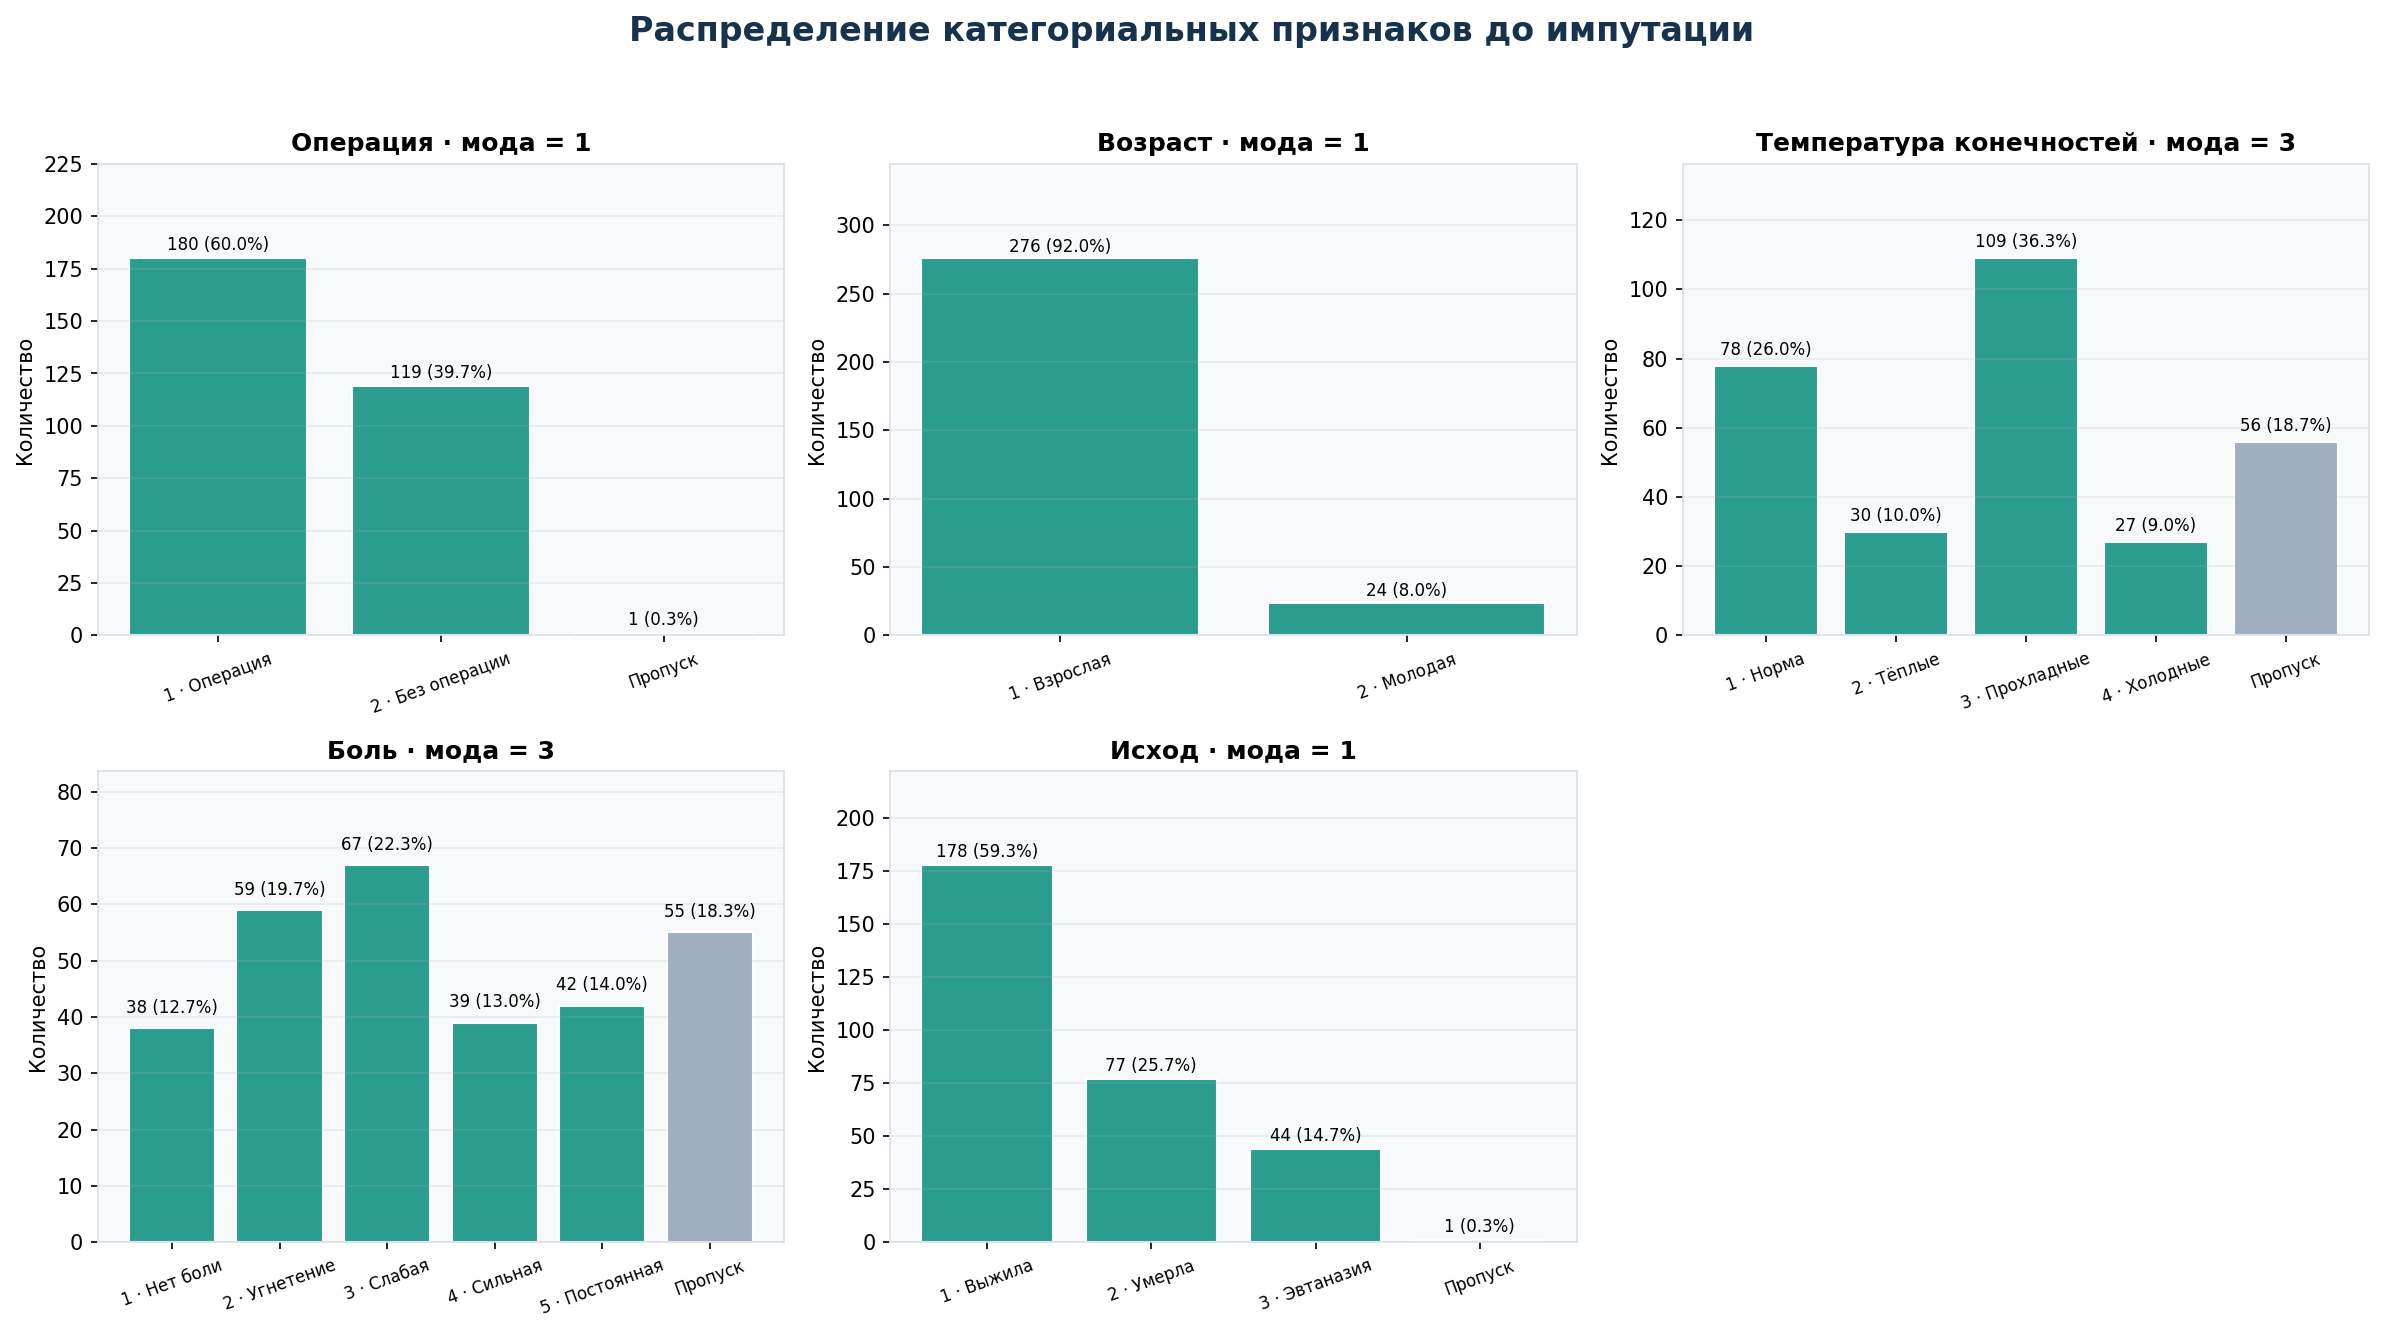

In [19]:
import matplotlib.pyplot as plt

_category_labels = {
    'surgery': {1: '1 · Операция', 2: '2 · Без операции'},
    'age': {1: '1 · Взрослая', 2: '2 · Молодая'},
    'temperature_of_extremities': {
        1: '1 · Норма', 2: '2 · Тёплые',
        3: '3 · Прохладные', 4: '4 · Холодные',
    },
    'pain': {
        1: '1 · Нет боли', 2: '2 · Угнетение', 3: '3 · Слабая',
        4: '4 · Сильная', 5: '5 · Постоянная',
    },
    'outcome': {1: '1 · Выжила', 2: '2 · Умерла', 3: '3 · Эвтаназия'},
}
_category_titles = {
    'surgery': 'Операция',
    'age': 'Возраст',
    'temperature_of_extremities': 'Температура конечностей',
    'pain': 'Боль',
    'outcome': 'Исход',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F7F9FB',
    'axes.edgecolor': '#D8E0E8',
    'axes.titleweight': 'bold',
    'font.size': 10,
})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.flat, categorical_columns):
    _value_counts = horse_data[column].value_counts(dropna=False)
    _values = sorted(value for value in _value_counts.index if pd.notna(value))
    if _value_counts.index.isna().any():
        _values.append(np.nan)

    _counts = [
        int(horse_data[column].isna().sum()) if pd.isna(value) else int(_value_counts.loc[value])
        for value in _values
    ]
    _labels = [
        'Пропуск' if pd.isna(value) else _category_labels[column][int(value)]
        for value in _values
    ]
    _colors = ['#A0AEC0' if pd.isna(value) else '#2A9D8F' for value in _values]
    _bars = ax.bar(_labels, _counts, color=_colors, edgecolor='white')

    for bar, count in zip(_bars, _counts):
        ax.text(bar.get_x() + bar.get_width() / 2, count + 2,
                f'{count} ({count / len(horse_data):.1%})',
                ha='center', va='bottom', fontsize=8)

    _mode = int(horse_data[column].mode().iloc[0])
    ax.set_title(f'{_category_titles[column]} · мода = {_mode}')
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.set_ylim(0, max(_counts) * 1.25)
    ax.grid(axis='y', alpha=0.2)

axes.flat[-1].axis('off')
fig.suptitle('Распределение категориальных признаков до импутации',
             fontsize=16, fontweight='bold', color='#17324D')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig


**Вывод по категориальным признакам.** После явно обозначенной коррекции `age: 9 → 2` все наблюдаемые коды соответствуют описанию. Моды: `surgery = 1`, `age = 1`, `temperature_of_extremities = 3`, `pain = 3`, `outcome = 1`. Пропуски не исключаются из частотного анализа и далее обрабатываются в разделе импутации.


### 2.2. Визуальный профиль непрерывных признаков

Гистограммы показывают асимметрию, крайние значения и положение медианы. Они не заменяют статистические тесты, но помогают оценить форму распределений до импутации.


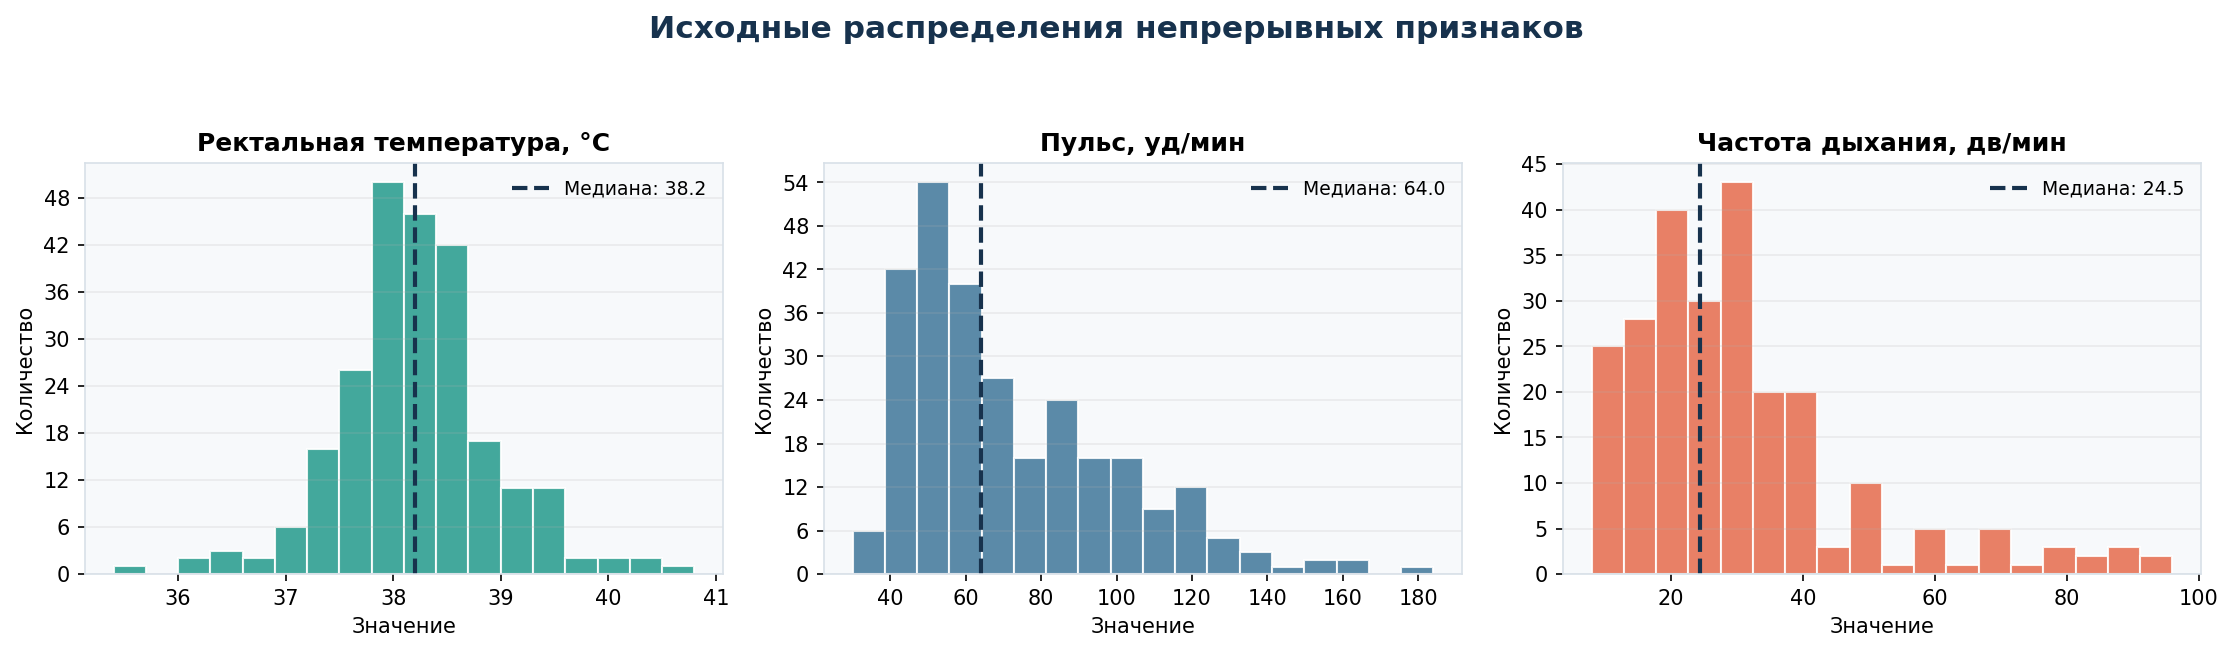

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

_portfolio_colors = ['#2A9D8F', '#457B9D', '#E76F51']
_portfolio_labels = {
    'rectal_temperature': 'Ректальная температура, °C',
    'pulse': 'Пульс, уд/мин',
    'respiratory_rate': 'Частота дыхания, дв/мин',
}
_viz_continuous_columns = [
    'rectal_temperature',
    'pulse',
    'respiratory_rate',
]

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F7F9FB',
    'axes.edgecolor': '#D8E0E8',
    'axes.titleweight': 'bold',
    'font.size': 10,
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, column, color in zip(axes, _viz_continuous_columns, _portfolio_colors):
    _series = horse_data[column].dropna()
    ax.hist(_series, bins=18, color=color, alpha=0.88, edgecolor='white')
    ax.axvline(_series.median(), color='#17324D', linestyle='--', linewidth=2,
               label=f'Медиана: {_series.median():.1f}')
    ax.set_title(_portfolio_labels[column])
    ax.set_xlabel('Значение')
    ax.set_ylabel('Количество')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Исходные распределения непрерывных признаков', fontsize=15, fontweight='bold', color='#17324D')
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig


### 2.3. Поиск выбросов


In [21]:
# найдём выбросы через межквартильный размах.

# размах есть смысл считать только для непрерывных числовых (не категориальных)
# признаков

# состави список таких столбцов
continuous_columns = [
    'rectal_temperature',
    'pulse',
    'respiratory_rate'
]

q1 = horse_data[continuous_columns].quantile(0.25)
q3 = horse_data[continuous_columns].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = (
    (horse_data[continuous_columns] < lower_bound) |
    (horse_data[continuous_columns] > upper_bound)
)

# смотрим сумму выбросов по столбцам

print(outliers.sum())


rectal_temperature    14
pulse                  5
respiratory_rate      17
dtype: int64


In [22]:
# итого, выбросы есть по столбцам:

# rectal_temperature            14
# pulse                          5
# respiratory_rate              17


In [23]:
#сколько всего выбросов

print('Количество отдельных выбросов:', outliers.sum().sum())
print('Количество строк хотя бы с одним выбросом:', outliers.any(axis=1).sum())


Количество отдельных выбросов: 36
Количество строк хотя бы с одним выбросом: 33


Найденые выбросы рассматриваются отдельно по каждому непрерывному признаку.


In [24]:
# посмотрим на выбросы по столбцу rectal_temperature

print('Данные по столбцу: ' + 'rectal_temperature')

q1 = horse_data['rectal_temperature'].quantile(0.25)
q3 = horse_data['rectal_temperature'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)


horse_data[~horse_data['rectal_temperature'].between(lower_bound, upper_bound, inclusive='both')  & horse_data['rectal_temperature'].notna()]

#добавил в финальны фильтр условие .notna() так как по умолчанию в выборосы добавлялись отсутствующие значения


Данные по столбцу: rectal_temperature


,surgery,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
20,1.0,1,39.9,72.0,60.0,1.0,5.0,1.0
44,1.0,1,35.4,140.0,24.0,3.0,4.0,3.0
54,2.0,1,40.3,114.0,36.0,3.0,2.0,3.0
75,1.0,2,39.7,100.0,NaN,3.0,2.0,3.0
80,1.0,1,36.4,98.0,35.0,3.0,4.0,2.0
91,2.0,1,40.3,114.0,36.0,3.0,2.0,2.0
99,2.0,1,39.6,108.0,51.0,3.0,2.0,1.0
118,1.0,1,36.5,78.0,30.0,1.0,5.0,1.0
141,2.0,1,36.0,42.0,30.0,NaN,NaN,2.0
238,2.0,1,36.1,88.0,NaN,3.0,3.0,3.0


Выбросы ректальной температуры не образуют очевидной системы и могут отражать реальные крайние состояния. Оснований считать их ошибками записи и удалять нет.


In [25]:
# посмотрим на выбросы по столбцу pulse

print('Данные по столбцу: ' + 'pulse')

q1 = horse_data['pulse'].quantile(0.25)
q3 = horse_data['pulse'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)


horse_data[~horse_data['pulse'].between(lower_bound, upper_bound, inclusive='both')  & horse_data['pulse'].notna()]


Данные по столбцу: pulse


,surgery,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
3,1.0,2,39.1,164.0,84.0,4.0,2.0,2.0
41,2.0,2,39.0,150.0,72.0,NaN,NaN,1.0
55,1.0,2,38.6,160.0,20.0,3.0,3.0,2.0
255,1.0,2,38.8,184.0,84.0,1.0,4.0,2.0
275,1.0,2,38.8,150.0,50.0,1.0,5.0,2.0


По критерию IQR обнаружены значения пульса от 150 до 184 ударов в минуту. Несмотря на статистическую экстремальность, эти значения не выходят за рамки возможных клинических проявлений боли или циркуляторного шока. Поэтому оснований считать их ошибками записи и удалять нет. Связь высокого пульса с исходом требует отдельной статистической проверки, поскольку количество таких наблюдений невелико.


In [26]:
# посмотрим на выбросы по столбцу respiratory_rate

print('Данные по столбцу: ' + 'respiratory_rate')

q1 = horse_data['respiratory_rate'].quantile(0.25)
q3 = horse_data['respiratory_rate'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)


horse_data[~horse_data['respiratory_rate'].between(lower_bound, upper_bound, inclusive='both')  & horse_data['respiratory_rate'].notna()]


Данные по столбцу: respiratory_rate


,surgery,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
3,1.0,2,39.1,164.0,84.0,4.0,2.0,2.0
39,1.0,2,39.2,146.0,96.0,NaN,NaN,2.0
41,2.0,2,39.0,150.0,72.0,NaN,NaN,1.0
82,1.0,2,38.1,100.0,80.0,3.0,3.0,1.0
84,1.0,1,37.8,60.0,80.0,1.0,2.0,1.0
103,1.0,2,38.0,140.0,68.0,1.0,3.0,1.0
106,1.0,1,38.3,52.0,96.0,NaN,NaN,1.0
120,1.0,1,39.4,54.0,66.0,1.0,2.0,1.0
125,1.0,1,38.0,42.0,68.0,4.0,3.0,1.0
186,1.0,1,39.3,64.0,90.0,2.0,NaN,1.0


По критерию IQR обнаружены высокие значения частоты дыхания от 66 до 96. В описании признака отмечаются значительные колебания частоты дыхания и её ограниченная диагностическая ценность. Поэтому найденные значения рассматриваются как статистические выбросы, но не как подтверждённые ошибки. Значения сохраняются без изменений.


### 2.4. Визуальная проверка IQR-выбросов

Диаграммы размаха показывают статистическую экстремальность значений. Они не доказывают, что наблюдение является ошибкой.


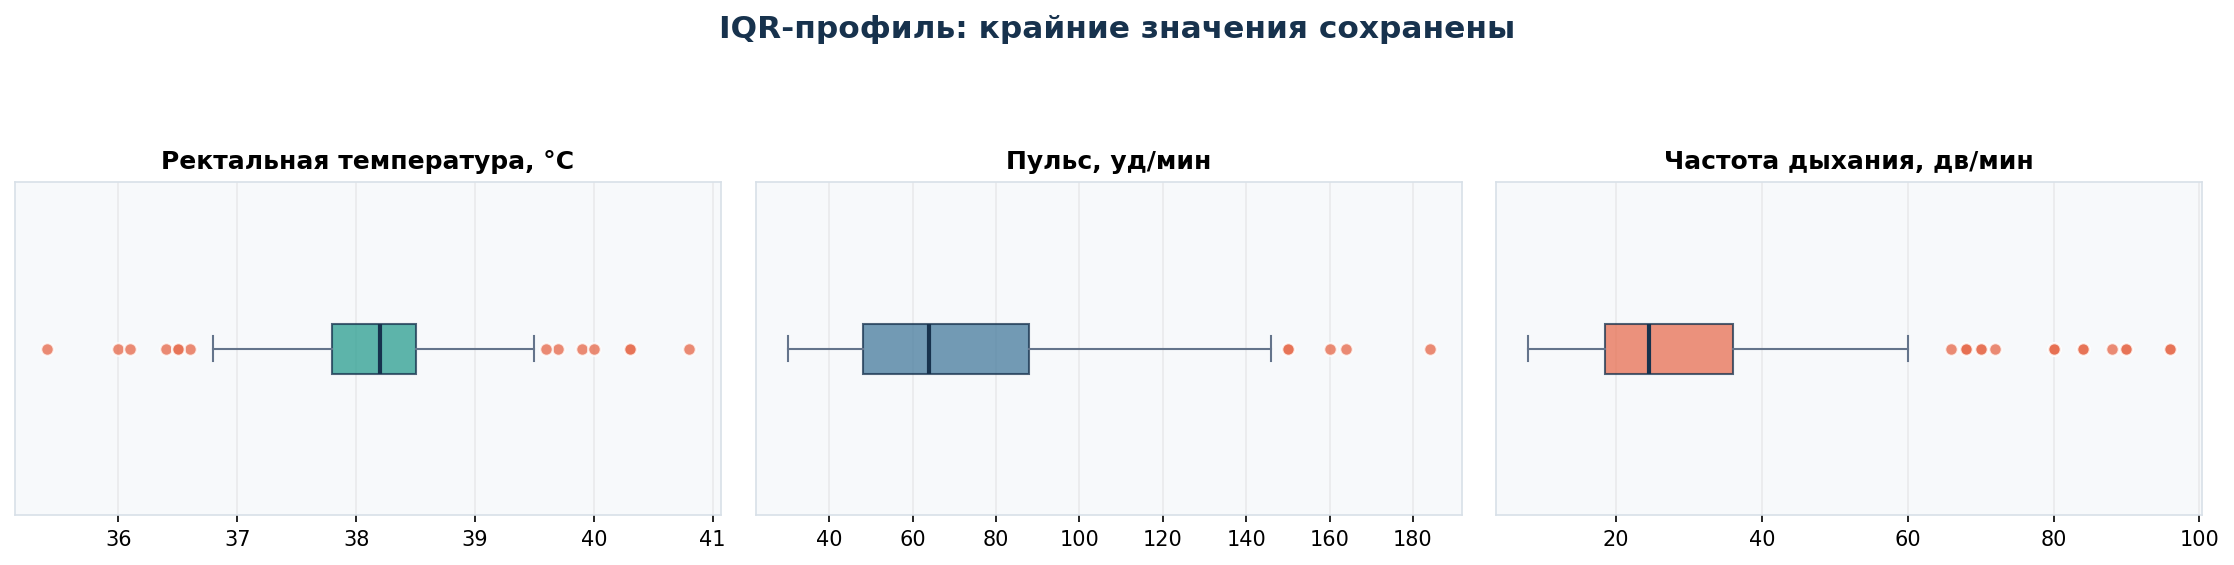

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, column, color in zip(axes, _viz_continuous_columns, _portfolio_colors):
    _values = horse_data[column].dropna()
    _box = ax.boxplot(
        _values,
        vert=False,
        patch_artist=True,
        boxprops={'facecolor': color, 'alpha': 0.75, 'edgecolor': '#17324D'},
        medianprops={'color': '#17324D', 'linewidth': 2},
        whiskerprops={'color': '#64748B'},
        capprops={'color': '#64748B'},
        flierprops={'marker': 'o', 'markerfacecolor': '#E76F51', 'markeredgecolor': 'white', 'alpha': 0.8},
    )
    ax.set_title(_portfolio_labels[column])
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.2)

fig.suptitle('IQR-профиль: крайние значения сохранены', fontsize=15, fontweight='bold', color='#17324D')
fig.tight_layout(rect=[0, 0, 1, 0.88])
fig


In [28]:
#посмотрим на выбросы отдельно от основного датафрема

horse_data_outliers = horse_data[outliers.any(axis=1)]

print('Количество строк с выбросами:', len(horse_data_outliers))

horse_data_outliers


Количество строк с выбросами: 33


,surgery,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
3,1.0,2,39.1,164.0,84.0,4.0,2.0,2.0
20,1.0,1,39.9,72.0,60.0,1.0,5.0,1.0
39,1.0,2,39.2,146.0,96.0,NaN,NaN,2.0
41,2.0,2,39.0,150.0,72.0,NaN,NaN,1.0
44,1.0,1,35.4,140.0,24.0,3.0,4.0,3.0
54,2.0,1,40.3,114.0,36.0,3.0,2.0,3.0
55,1.0,2,38.6,160.0,20.0,3.0,3.0,2.0
75,1.0,2,39.7,100.0,NaN,3.0,2.0,3.0
80,1.0,1,36.4,98.0,35.0,3.0,4.0,2.0
82,1.0,2,38.1,100.0,80.0,3.0,3.0,1.0


In [29]:
# создадим датафрейм без выбросов для сравнительного анализа
horse_data_clean = horse_data[~outliers.any(axis=1)]

print('Размер исходного датафрейма:', horse_data.shape)
print('Размер датафрейма без выбросов:', horse_data_clean.shape)

horse_data_clean


Размер исходного датафрейма: (300, 8)
Размер датафрейма без выбросов: (267, 8)


,surgery,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
0,2.0,1,38.5,66.0,28.0,3.0,5.0,2.0
1,1.0,1,39.2,88.0,20.0,NaN,3.0,3.0
2,2.0,1,38.3,40.0,24.0,1.0,3.0,1.0
4,2.0,1,37.3,104.0,35.0,NaN,NaN,2.0
5,2.0,1,NaN,NaN,NaN,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...
293,1.0,1,NaN,78.0,24.0,3.0,NaN,3.0
294,2.0,1,38.5,40.0,16.0,1.0,2.0,1.0
296,2.0,1,37.2,72.0,24.0,3.0,4.0,3.0
297,1.0,1,37.5,72.0,30.0,4.0,4.0,2.0


In [30]:
#Выведем статистики для датафрейма без выбросов

print('Среднее арифметическое: ')
print(horse_data_clean[continuous_columns].mean())
print('-----------------------')
print('Медиана: ')
print(horse_data_clean[continuous_columns].median())
print('-----------------------')
print('Мода: ')
print(horse_data_clean[continuous_columns].mode().iloc[0])
print('-----------------------')
print('Стандартное отклонение: ')
print(horse_data_clean[continuous_columns].std())
print('-----------------------')
print('Дисперсия: ')
print(horse_data_clean[continuous_columns].var())


Среднее арифметическое: 
rectal_temperature    38.133971
pulse                 68.164609
respiratory_rate      26.202830
dtype: float64
-----------------------
Медиана: 
rectal_temperature    38.1
pulse                 60.0
respiratory_rate      24.0
dtype: float64
-----------------------
Мода: 
rectal_temperature    38.0
pulse                 48.0
respiratory_rate      20.0
Name: 0, dtype: float64
-----------------------
Стандартное отклонение: 
rectal_temperature     0.559914
pulse                 24.604593
respiratory_rate      11.206438
dtype: float64
-----------------------
Дисперсия: 
rectal_temperature      0.313504
pulse                 605.386015
respiratory_rate      125.584257
dtype: float64


In [31]:
#Проведём сравнительный анализ базовых статистик между датафреймом с выбросами и без

print('Разница Среднего арифметического: ')
print(horse_data[continuous_columns].mean() - horse_data_clean[continuous_columns].mean())
print('-----------------------')
print('Разница Медианы: ')
print(horse_data[continuous_columns].median() - horse_data_clean[continuous_columns].median())
print('-----------------------')
print('Разница в Моде: ')
print(horse_data[continuous_columns].mode().iloc[0] - horse_data_clean[continuous_columns].mode().iloc[0])
print('-----------------------')
print('Разница в стандартном отклонении: ')
print(horse_data[continuous_columns].std() - horse_data_clean[continuous_columns].std())
print('-----------------------')
print('Разница дисперсии: ')
print(horse_data[continuous_columns].var() - horse_data_clean[continuous_columns].var())


Разница Среднего арифметического: 
rectal_temperature    0.033945
pulse                 3.748434
respiratory_rate      4.214525
dtype: float64
-----------------------
Разница Медианы: 
rectal_temperature    0.1
pulse                 4.0
respiratory_rate      0.5
dtype: float64
-----------------------
Разница в Моде: 
rectal_temperature    0.0
pulse                 0.0
respiratory_rate      0.0
Name: 0, dtype: float64
-----------------------
Разница в стандартном отклонении: 
rectal_temperature    0.172375
pulse                 4.025963
respiratory_rate      6.435793
dtype: float64
-----------------------
Разница дисперсии: 
rectal_temperature      0.222743
pulse                 214.322760
respiratory_rate      185.664071
dtype: float64


In [32]:
# Также посмотрим на разницу общих статистик
print(horse_data[continuous_columns].describe() - horse_data_clean[continuous_columns].describe())


       rectal_temperature      pulse  respiratory_rate
count           31.000000  33.000000         30.000000
mean             0.033945   3.748434          4.214525
std              0.172375   4.025963          6.435793
min             -1.400000   0.000000          0.000000
25%              0.000000   0.000000          1.000000
50%              0.100000   4.000000          0.500000
75%              0.000000   2.000000          4.000000
max              1.300000  48.000000         36.000000


Исключение всех строк, содержащих хотя бы один статистический выброс, приводит к удалению 33 из 300 наблюдений и заметному изменению статистик пульса и частоты дыхания. При этом найденные значения могут отражать реальные тяжёлые клинические состояния. Поэтому строки не удаляются, а датафрейм без выбросов используется только для сравнительного анализа. Дальнейшая работа проводится с исходным датафреймом horse_data.


In [33]:
# Проверим распределение записей в столбцах на нормальность

# импортируем функцию статистического теста, с помощью которого можно проверить распределены ли данные нормально

from scipy.stats import shapiro


In [34]:
#проверяем только числовые данные, категориальные отбрасываем,
#так как их распределение не имеет смысла разбирать

rectal_temperature_p = shapiro(horse_data['rectal_temperature'].dropna()).pvalue
pulse_p = shapiro(horse_data['pulse'].dropna()).pvalue
respiratory_rate_p = shapiro(horse_data['respiratory_rate'].dropna()).pvalue

print('p-значение для ректальной температуры (тест Шапиро): ', rectal_temperature_p)
print('p-значение для пульса (тест Шапиро): ', pulse_p)
print('p-значение для частоты дыхания (тест Шапиро): ', respiratory_rate_p)


p-значение для ректальной температуры (тест Шапиро):  0.0005172908359663076
p-значение для пульса (тест Шапиро):  1.1620529142072034e-11
p-значение для частоты дыхания (тест Шапиро):  6.292669411445838e-15


In [35]:
# далее мы будем сравнивать значения p-value с порогом уровня значимости
# это значение 0.05

# напишем функцию применения правила трёх сигм

def find_outliers_sigma(series):
  mean = series.mean() # считаем среднее
  std = series.std() # считаем стандартное отклонение
  lower = mean - 3 * std # считаем нижнюю границу среднее значение минус 3 сигмы
  upper = mean + 3 * std # считаем верхнюю границу среднее значение плюс 3 сигмы
  return series[(series < lower) | (series > upper)]
  #вернёт нам данные не входящие в диапазон от нижней до верхней границы

if rectal_temperature_p > 0.05: # проверка нормальности распределения
  rectal_temperature_outliers = find_outliers_sigma(horse_data['rectal_temperature'])
  print("Выбросы по ректальной температуре (правило 3 сигм): ", rectal_temperature_outliers.values)
else:
  print("Распределение ректальной температуры не является нормальным - правило 3 сигм не применяется.")


if pulse_p > 0.05:
  pulse_outliers = find_outliers_sigma(horse_data['pulse'])
  print("Выбросы по пульсу (правило 3 сигм): ", pulse_outliers.values)
else:
  print("Распределение пульса не является нормальным - правило 3 сигм не применяется.")


if respiratory_rate_p > 0.05:
  respiratory_rate_outliers = find_outliers_sigma(horse_data['respiratory_rate'])
  print("Выбросы по частоте дыхания (правило 3 сигм): ", respiratory_rate_outliers.values)
else:
  print("Распределение частоты дыхания не является нормальным - правило 3 сигм не применяется.")


Распределение ректальной температуры не является нормальным - правило 3 сигм не применяется.
Распределение пульса не является нормальным - правило 3 сигм не применяется.
Распределение частоты дыхания не является нормальным - правило 3 сигм не применяется.


При уровне значимости 0,05 для ректальной температуры, пульса и частоты дыхания отклоняется гипотеза о нормальном распределении. Поэтому правило трёх стандартных отклонений не применяется; для поиска статистических выбросов используется межквартильный размах.


> **Промежуточное решение.** Дальнейший анализ проводится на `horse_data`: в `age` исправлена кодировка `9 → 2`, а все статистические выбросы сохранены.


### Задача 3. Работа с пропусками

Рассчитать количество пропусков, обосновать метод импутации для каждого признака и сформировать датафрейм без пропусков.


In [36]:
#проверяем есть ли вообще пропуски

horse_data.isnull().values.any()


np.True_

In [37]:
# считаем сколько всего пропусков

horse_data.isnull().sum().sum()


np.int64(255)

In [38]:
# проверяем колличество пропусков по каждому столбцу

horse_data.isnull().sum()


surgery                        1
age                            0
rectal_temperature            60
pulse                         24
respiratory_rate              58
temperature_of_extremities    56
pain                          55
outcome                        1

In [39]:
#смотрим количество пропусков по столбцам в процентах

(horse_data.isna().mean() * 100).round(2)

# с округлением до двух знаков после запятой


surgery                        0.33
age                            0.00
rectal_temperature            20.00
pulse                          8.00
respiratory_rate              19.33
temperature_of_extremities    18.67
pain                          18.33
outcome                        0.33

### 3.1. Профиль пропусков

Визуально основная нагрузка приходится на `rectal_temperature`, `respiratory_rate`, `temperature_of_extremities` и `pain`. Однако порядок импутации определяется не только долей пропусков, но и содержательными связями между признаками.


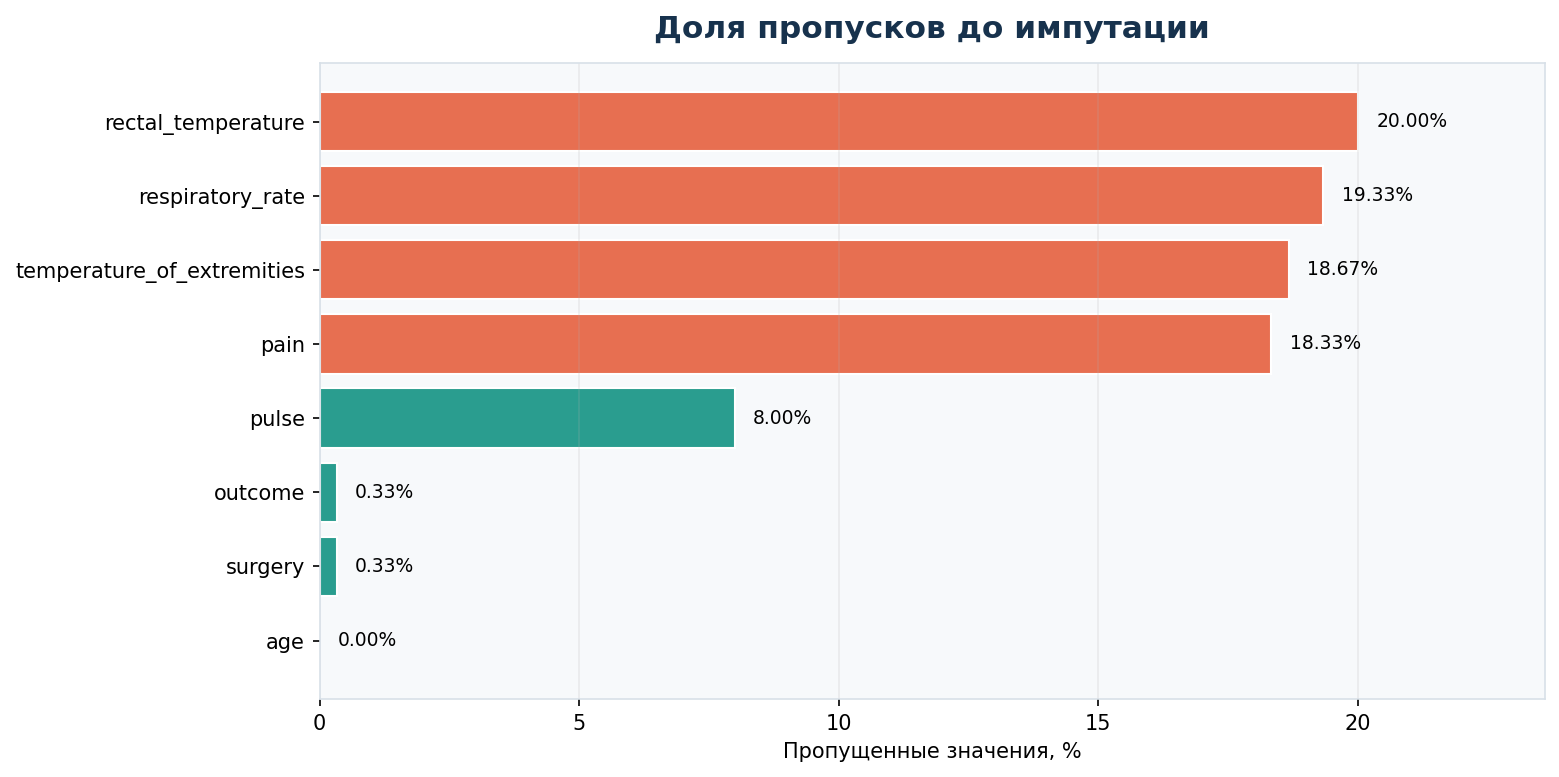

In [40]:
_missing_pct = (horse_data.isna().mean() * 100).sort_values()
_missing_colors = ['#2A9D8F' if value < 10 else '#E9C46A' if value < 18 else '#E76F51' for value in _missing_pct]

fig, ax = plt.subplots(figsize=(10.5, 5.3))
_bars = ax.barh(_missing_pct.index, _missing_pct.values, color=_missing_colors, edgecolor='white')
for bar, value in zip(_bars, _missing_pct.values):
    ax.text(value + 0.35, bar.get_y() + bar.get_height() / 2, f'{value:.2f}%', va='center', fontsize=9)

ax.set_title('Доля пропусков до импутации', fontsize=15, fontweight='bold', color='#17324D', pad=12)
ax.set_xlabel('Пропущенные значения, %')
ax.set_xlim(0, max(_missing_pct.max() * 1.18, 1))
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
fig


#### Совместное появление пропусков

Подсчёт пропусков по строкам показывает, насколько часто они встречаются одновременно. Это дополняет доли по отдельным столбцам и помогает оценить последствия удаления неполных наблюдений.


                    Количество строк  Доля строк, %
Пропусков в строке                                 
0                                154           51.3
1                                 77           25.7
2                                 47           15.7
3                                 12            4.0
4                                  2            0.7
5                                  8            2.7

Полностью заполненных строк: 154
Строк минимум с двумя пропусками: 69


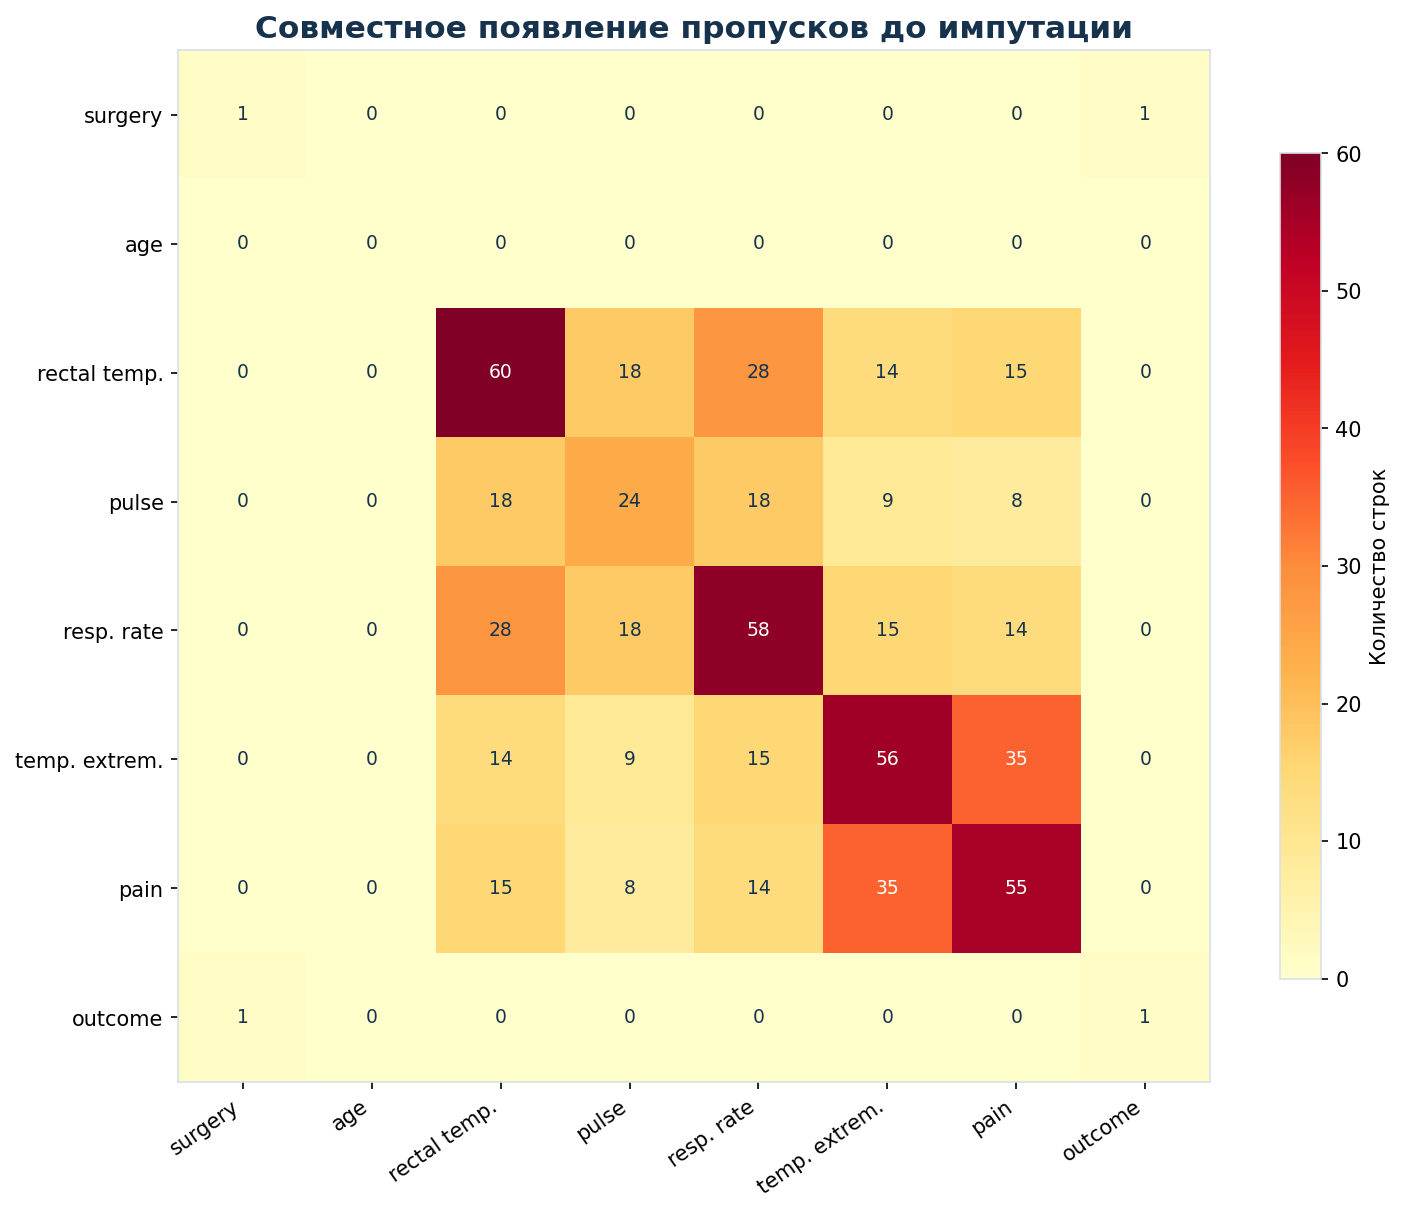

In [41]:
_missing_per_row = horse_data.isna().sum(axis=1)
missingness_by_row = pd.DataFrame({
    'Количество строк': _missing_per_row.value_counts().sort_index(),
})
missingness_by_row.index.name = 'Пропусков в строке'
missingness_by_row['Доля строк, %'] = (
    missingness_by_row['Количество строк'] / len(horse_data) * 100
).round(1)

print(missingness_by_row)
print()
print('Полностью заполненных строк:', int((_missing_per_row == 0).sum()))
print('Строк минимум с двумя пропусками:', int((_missing_per_row >= 2).sum()))

_missing_indicator = horse_data.isna().astype(int)
missingness_cooccurrence = _missing_indicator.T.dot(_missing_indicator)
_short_names = ['surgery', 'age', 'rectal temp.', 'pulse', 'resp. rate',
                'temp. extrem.', 'pain', 'outcome']

fig, ax = plt.subplots(figsize=(10.5, 8.2))
_image = ax.imshow(missingness_cooccurrence.values, cmap='YlOrRd', vmin=0)
for row in range(len(missingness_cooccurrence)):
    for column in range(len(missingness_cooccurrence)):
        value = int(missingness_cooccurrence.iloc[row, column])
        ax.text(column, row, str(value), ha='center', va='center',
                color='white' if value >= 35 else '#17324D', fontsize=9)

ax.set_xticks(range(len(_short_names)))
ax.set_xticklabels(_short_names, rotation=35, ha='right')
ax.set_yticks(range(len(_short_names)))
ax.set_yticklabels(_short_names)
ax.set_title('Совместное появление пропусков до импутации',
             fontsize=15, fontweight='bold', color='#17324D')
fig.colorbar(_image, ax=ax, shrink=0.8, label='Количество строк')
fig.tight_layout()
fig


In [42]:
# Повторно выведем выбросы, для сравнения с пропущенными значениями

print(outliers.sum())


rectal_temperature    14
pulse                  5
respiratory_rate      17
dtype: int64


#### 3.1. Исходное качество данных

| Признак | Пропуски | Доля | IQR-выбросы |
|---|---:|---:|---:|
| `surgery` | 1 | 0,33% | не применяется |
| `age` | 0 | 0,00% | не применяется |
| `rectal_temperature` | 60 | 20,00% | 14 |
| `pulse` | 24 | 8,00% | 5 |
| `respiratory_rate` | 58 | 19,33% | 17 |
| `temperature_of_extremities` | 56 | 18,67% | не применяется |
| `pain` | 55 | 18,33% | не применяется |
| `outcome` | 1 | 0,33% | не применяется |


### 3.2. Описание выбранных признаков


surgery (Операция)
1 = Да, была проведена операция
2 = Лечение проводилось без операции

---


age (Возраст)
1 = Взрослая лошадь
2 = Молодая лошадь (младше 6 месяцев)


---


rectal_temperature (Ректальная температура)

Непрерывная числовая переменная.
Измеряется в градусах Цельсия.
Повышенная температура может быть связана с инфекцией.
На поздней стадии шока температура может снижаться.
Нормальная температура — 37,8 °C.
Этот показатель обычно изменяется по мере развития патологического процесса. Например, первоначально температура может быть нормальной, затем повыситься из-за поражения, а при переходе лошади в состояние шока вновь пройти через нормальный диапазон и снизиться.


---


pulse (Пульс)
Непрерывная числовая переменная.
Частота сердечных сокращений в ударах в минуту.
Отражает состояние сердечно-сосудистой системы. Нормальный пульс взрослой лошади — 30–40 ударов в минуту.
Пульс ниже нормы встречается редко, хотя у спортивных лошадей он может составлять 20–25 ударов в минуту.
У животных с болезненными поражениями или циркуляторным шоком частота сердечных сокращений может быть повышена.


---


respiratory_rate (Частота дыхания)
Непрерывная числовая переменная.
Нормальная частота — 8–10 дыхательных движений в минуту.
Диагностическая ценность показателя сомнительна из-за значительных колебаний.


---


temperature_of_extremities (Температура конечностей)
Субъективный показатель периферического кровообращения.
Возможные значения:
1 = Нормальные
2 = Тёплые
3 = Прохладные
4 = Холодные
Прохладные или холодные конечности могут указывать на шок.
Горячие конечности обычно должны сочетаться с повышенной ректальной температурой.


---


pain (Боль)
Субъективная оценка уровня боли у лошади.
Возможные значения:
1 = Бодрая, боли нет
2 = Угнетённое состояние
3 = Периодическая слабая боль
4 = Периодическая сильная боль
5 = Постоянная сильная боль
Переменную не следует рассматривать как порядковую или дискретную.
В целом, чем сильнее боль, тем выше вероятность необходимости хирургического вмешательства.
Предшествующее обезболивание может частично скрывать реальный уровень боли.


---


outcome (Исход)
Что в конечном итоге произошло с лошадью?
1 = Выжила
2 = Умерла
3 = Была подвергнута эвтаназии


### 3.3. Выбор методов импутации

Наблюдения не упорядочены во времени, поэтому `forward fill` и `backward fill` не применяются.


Замена на произвольную константу, например `0`, не имеет содержательного смысла. Если в группе нет единственной моды — наблюдений нет или несколько категорий встречаются одинаково часто — применяется заранее обозначенное резервное правило.


Используются:

- медиана для непрерывных признаков;
- мода для категориальных признаков;
- группировка по одному или нескольким связанным признакам.


In [43]:
# создаём отдельный датафрейм для заполнения пропусков

fill_horse_data = horse_data.copy()


In [44]:
# Возвращаем значение только тогда, когда мода в группе единственная.
# Если мод несколько или наблюдений нет, оставляем NaN для резервного правила.
def _single_mode(values):
    modes = values.mode()
    if len(modes) == 1:
        return modes.iloc[0]
    return np.nan


In [45]:
#surgery

'''Из описания датасета:
surgery (Операция)
 1 = Да, была проведена операция
 2 = Лечение проводилось без операции'''

#предположим связь операции с болью (столбец 'pain')


print(fill_horse_data.groupby('pain')['surgery'].agg(_single_mode))

'''
pain
1.0    2.0
2.0    1.0
3.0    1.0
4.0    1.0
5.0    1.0
Name: surgery
'''

# Для каждой категории боли рассчитано наиболее частое значение surgery.
# Это не означает строгой зависимости,
# но позволяет использовать категорию боли для заполнения единственного пропуска в surgery.


pain
1.0    2.0
2.0    1.0
3.0    1.0
4.0    1.0
5.0    1.0
Name: surgery, dtype: float64


In [46]:
# Заполняем пропуски в столбце surgery модой, сгруппированной по столбцу pain

fill_horse_data['surgery'] = fill_horse_data['surgery'].fillna(fill_horse_data.groupby('pain')
                                                                   ['surgery'].transform(_single_mode))

#проверим число пропусков после заполнения
print(fill_horse_data['surgery'].isna().sum())


0


In [47]:
# переходим к столбцу outcome

'''Используем подсказки из описания датасета:
outcome (Исход) Что в конечном итоге произошло с лошадью?
1 = Выжила 2 = Умерла 3 = Была подвергнута эвтаназии'''
 # что может быть связано с "исходом?"

# предполагаем, что outcome может быть связан с surgery и pain.
# все три признака категориальные, поэтому используем моду.


print(fill_horse_data.groupby('surgery')['outcome'].agg(_single_mode))

# в обеих группах surgery мода outcome равна 1.
# следовательно, surgery отдельно не помогает выбрать значение для пропуска.

'''
surgery
1.0    1.0
2.0    1.0
Name: outcome
'''

print(fill_horse_data.groupby('pain')['outcome'].agg(_single_mode))

'''
1.0    1.0
2.0    1.0
3.0    1.0
4.0    2.0
5.0    2.0
Name: outcome
'''

# для pain от 1 до 3 наиболее частый outcome равен 1.
# для pain 4 и 5 наиболее частый outcome равен 2.
# поэтому pain можно использовать для заполнения пропуска в outcome.


surgery
1.0    1.0
2.0    1.0
Name: outcome, dtype: float64
pain
1.0    1.0
2.0    1.0
3.0    1.0
4.0    2.0
5.0    2.0
Name: outcome, dtype: float64


In [48]:
# Заполняем пропуски в столбце outcome модой, сгруппированной по столбцу pain

fill_horse_data['outcome'] = fill_horse_data['outcome'].fillna(fill_horse_data.groupby('pain')
                                                                   ['outcome'].transform(_single_mode))

#проверим число пропусков после заполнения
print(fill_horse_data['outcome'].isna().sum())


0


In [49]:
# переходим к столбцу pulse

'''pulse (Пульс) Непрерывная числовая переменная.
Частота сердечных сокращений в ударах в минуту.
Отражает состояние сердечно-сосудистой системы.
Нормальный пульс взрослой лошади — 30–40 ударов в минуту.
Пульс ниже нормы встречается редко,
хотя у спортивных лошадей он может составлять 20–25 ударов в минуту.
У животных с болезненными поражениями или
циркуляторным шоком частота сердечных сокращений может быть повышена.'''

 # что может быть связано с "пульсом?"

 # допускаем что: age и surgery

print(fill_horse_data.groupby('age')['pulse'].median())

'''
age
1     60.0
2    124.0
Name: pulse

'''
#медиана по пульсу выше для молодых лошадей

print(fill_horse_data.groupby('surgery')['pulse'].median())

'''
1.0    70.0
2.0    56.0
Name: pulse
'''
#медиана по пульсу выше для лошадей прошедших лечение с операцией


age
1     60.0
2    124.0
Name: pulse, dtype: float64
surgery
1.0    70.0
2.0    56.0
Name: pulse, dtype: float64


In [50]:
# Заполняем пропуски в столбце pulse медианой, сгруппированной по столбцам age surgery

fill_horse_data['pulse'] = fill_horse_data['pulse'].fillna(fill_horse_data.groupby(['age', 'surgery'])\
                                                                   ['pulse'].transform('median'))

#проверим число пропусков после заполнения
print(fill_horse_data['pulse'].isna().sum())


0


In [51]:
# переходим к столбцу rectal_temperature

'''rectal_temperature (Ректальная температура)
Непрерывная числовая переменная. Измеряется в градусах Цельсия.
Повышенная температура может быть связана с инфекцией.
На поздней стадии шока температура может снижаться.
Нормальная температура — 37,8 °C.
Этот показатель обычно изменяется по мере развития патологического процесса.
Например, первоначально температура может быть нормальной,
затем повыситься из-за поражения,
а при переходе лошади в состояние шока вновь пройти через нормальный диапазон и снизиться.
'''

 # что может быть связано с "ректальной температурой?"

 # допускаем что: age


print(fill_horse_data.groupby('age')['rectal_temperature'].median())

'''
В качестве группирующего признака выбран возраст.
Возраст не содержит пропусков, а медианы ректальной температуры
для взрослых и молодых лошадей различаются: 38.1 и 38.6.

Поэтому пропуски заполняются медианой соответствующей возрастной группы.
Медиана устойчива к найденным выбросам, хотя её использование
несколько уменьшает вариативность признака.
'''


age
1    38.1
2    38.6
Name: rectal_temperature, dtype: float64


In [52]:
# Заполняем пропуски в столбце rectal_temperature медианой, сгруппированной по столбцам age

fill_horse_data['rectal_temperature'] = fill_horse_data['rectal_temperature'].fillna(fill_horse_data.groupby('age')\
                                                                   ['rectal_temperature'].transform('median'))

#проверим число пропусков после заполнения
print(fill_horse_data['rectal_temperature'].isna().sum())


0


In [53]:
# переходим к столбцу temperature_of_extremities
'''
temperature_of_extremities (Температура конечностей)
Субъективный показатель периферического кровообращения.
Возможные значения:
1 = Нормальные
2 = Тёплые
3 = Прохладные
4 = Холодные
Прохладные или холодные конечности могут указывать на шок
Горячие конечности обычно должны сочетаться с повышенной ректальной температурой.
'''

# rectal_temperature и pulse предположительно связаны с temperature_of_extremities

print(fill_horse_data.groupby('rectal_temperature')['temperature_of_extremities'].agg(_single_mode))

print(fill_horse_data.groupby('pulse')['temperature_of_extremities'].agg(_single_mode))

'''
Связь с rectal_temperature оказалась неоднозначной.
Пульс выбран в качестве группирующего признака, поскольку он отражает
состояние сердечно-сосудистой системы, а температура конечностей
характеризует периферическое кровообращение. Оба показателя могут
изменяться при шоке.
Поэтому пропуски temperature_of_extremities сначала заполняются модой
для соответствующего значения pulse.
'''


rectal_temperature
35.4    3.0
36.0    NaN
36.1    3.0
36.4    3.0
36.5    NaN
36.6    3.0
36.8    NaN
36.9    2.0
37.0    NaN
37.1    3.0
37.2    3.0
37.3    1.0
37.4    NaN
37.5    1.0
37.6    3.0
37.7    3.0
37.8    1.0
37.9    1.0
38.0    NaN
38.1    3.0
38.2    1.0
38.3    NaN
38.4    1.0
38.5    3.0
38.6    2.0
38.7    NaN
38.8    1.0
38.9    3.0
39.0    3.0
39.1    NaN
39.2    4.0
39.3    NaN
39.4    NaN
39.5    3.0
39.6    3.0
39.7    3.0
39.9    1.0
40.0    3.0
40.3    3.0
40.8    3.0
Name: temperature_of_extremities, dtype: float64
pulse
30.0     NaN
36.0     1.0
38.0     3.0
40.0     1.0
42.0     NaN
44.0     3.0
45.0     NaN
46.0     1.0
48.0     1.0
49.0     NaN
50.0     NaN
52.0     1.0
54.0     1.0
56.0     NaN
60.0     3.0
64.0     1.0
65.0     NaN
66.0     3.0
68.0     2.0
70.0     3.0
72.0     4.0
75.0     NaN
76.0     NaN
78.0     3.0
80.0     3.0
82.0     3.0
84.0     3.0
86.0     NaN
88.0     3.0
90.0     NaN
92.0     1.0
96.0     3.0
98.0     3.0
100.0    3.0
104.

#### Проверка однозначности групповой моды

`mode().iloc[0]` всегда выбирает первый код, даже если несколько категорий встречаются одинаково часто. Чтобы не создавать скрытого смещения в пользу меньшего кода, групповое значение используется только при единственной моде; остальные строки переходят к общей моде как резервному правилу.


In [54]:
_temperature_modes_by_pulse = (
    fill_horse_data.groupby('pulse')['temperature_of_extremities']
    .agg(lambda values: values.mode().tolist())
)
_tied_pulse_groups = _temperature_modes_by_pulse[
    _temperature_modes_by_pulse.apply(len) > 1
]
_temperature_missing_before_group = fill_horse_data['temperature_of_extremities'].isna()
_missing_rows_in_tied_groups = int(
    fill_horse_data.loc[_temperature_missing_before_group, 'pulse']
    .isin(_tied_pulse_groups.index)
    .sum()
)

print('Групп pulse с несколькими модами:', len(_tied_pulse_groups))
print('Заполняемых строк, затронутых ничьей:', _missing_rows_in_tied_groups)
_tied_pulse_groups


Групп pulse с несколькими модами: 10
Заполняемых строк, затронутых ничьей: 8


pulse
42.0     [1.0, 2.0, 3.0]
45.0          [2.0, 3.0]
50.0          [1.0, 3.0]
56.0          [1.0, 2.0]
76.0          [1.0, 3.0]
86.0     [1.0, 3.0, 4.0]
90.0     [1.0, 3.0, 4.0]
112.0         [3.0, 4.0]
124.0         [1.0, 3.0]
140.0         [1.0, 3.0]

In [55]:
# Заполняем пропуски в столбце temperature_of_extremities модой, сгруппированной по столбцам pulse

fill_horse_data['temperature_of_extremities'] = (fill_horse_data['temperature_of_extremities'].fillna(fill_horse_data.groupby('pulse')
        ['temperature_of_extremities'].transform(_single_mode)))


#проверим число пропусков после заполнения
print(fill_horse_data['temperature_of_extremities'].isna().sum())


15


> После заполнения только однозначно определённой групповой модой осталось 15 пропусков: для части значений пульса нет наблюдений температуры конечностей, а в части групп несколько категорий встречаются одинаково часто.


In [56]:
# Для оставшихся строк невозможно определить групповую моду,
# поэтому заполняем их общей модой исходного столбца

fill_horse_data['temperature_of_extremities'] = (fill_horse_data['temperature_of_extremities'].fillna
 (horse_data['temperature_of_extremities'].mode()[0]))

print('После заполнения общей модой:', fill_horse_data['temperature_of_extremities'].isna().sum())

'''
Сначала пропуски заполняются модой температуры конечностей для соответствующего значения пульса.
Для оставшихся строк однозначную групповую моду определить невозможно: либо в группе нет
известных наблюдений температуры конечностей, либо несколько категорий имеют равную частоту.
Оставшиеся пропуски заполняются общей модой исходного столбца, равной 3.'''


После заполнения общей модой: 0


In [57]:
# переходим к столбцу pain

'''pain (Боль) Субъективная оценка уровня боли у лошади.
Возможные значения:
1 = Бодрая, боли нет
2 = Угнетённое состояние
3 = Периодическая слабая боль
4 = Периодическая сильная боль
5 = Постоянная сильная боль
'''

 # что может быть связано с "болью" ?
 # можем предположить, что сильная боль может быть связана с необходимостью
 # хирургического вмешательства и исходом

print(fill_horse_data.groupby('surgery')['pain'].agg(_single_mode))
'''
surgery
1.0    3.0
2.0    1.0
Name: pain
'''


print(fill_horse_data.groupby('outcome')['pain'].agg(_single_mode))
'''
outcome
1.0    3.0
2.0    5.0
3.0    2.0
Name: pain
'''


surgery
1.0    3.0
2.0    1.0
Name: pain, dtype: float64
outcome
1.0    3.0
2.0    5.0
3.0    2.0
Name: pain, dtype: float64


In [58]:
# Заполняем пропуски в столбце pain модой, сгруппированной по столбцам surgery и outcome

fill_horse_data['pain'] = fill_horse_data['pain'].fillna(fill_horse_data.groupby(['surgery', 'outcome'])
                                                                   ['pain'].transform(_single_mode))

#проверим число пропусков после заполнения
print(fill_horse_data['pain'].isna().sum())


0


In [59]:
# переходим к столбцу respiratory_rate

'''(Частота дыхания) Непрерывная числовая переменная.
Нормальная частота — 8–10 дыхательных движений в минуту.
Диагностическая ценность показателя сомнительна из-за значительных колебаний.'''

 # что может быть связано с "частотой дыхания?"

# Проверяем частоту дыхания в зависимости от пульса


print(fill_horse_data.groupby('pulse')['respiratory_rate'].median())

print(horse_data[['pulse', 'respiratory_rate']].corr(method='spearman'))

'''
Коэффициент корреляции Спирмена между пульсом и частотой дыхания
составляет примерно 0.47, что указывает на умеренную положительную связь.

Поэтому на первом этапе пропуски заполняются медианой внутри
совместных групп pulse и age.

Для сочетаний пульса и возраста, в которых невозможно рассчитать медиану,
используется медиана частоты дыхания соответствующей возрастной группы.
'''


pulse
30.0     15.0
36.0     16.0
38.0     20.0
40.0     17.0
42.0     25.0
44.0     14.0
45.0     14.0
46.0      NaN
48.0     20.0
49.0      NaN
50.0     32.0
52.0     20.0
54.0     27.0
56.0     32.0
60.0     28.0
64.0     36.0
65.0     24.0
66.0     21.5
68.0     20.0
70.0     19.0
72.0     30.0
75.0     36.0
76.0     23.0
78.0     27.0
80.0     38.0
82.0     12.0
84.0     36.0
86.0     20.0
88.0     30.0
90.0     35.0
92.0     28.0
96.0     30.0
98.0     35.0
100.0    37.0
104.0    37.5
108.0    51.0
110.0    35.0
112.0    16.0
114.0    36.0
120.0    48.0
124.0    62.0
128.0    36.0
129.0    48.0
130.0    38.0
132.0     NaN
136.0    48.0
140.0    46.0
146.0    96.0
150.0    61.0
160.0    20.0
164.0    84.0
184.0    84.0
Name: respiratory_rate, dtype: float64
                     pulse  respiratory_rate
pulse             1.000000          0.472463
respiratory_rate  0.472463          1.000000


#### Пульс и частота дыхания

Точечная диаграмма дополняет коэффициент Спирмена и показывает общую положительную тенденцию при значительном разбросе.


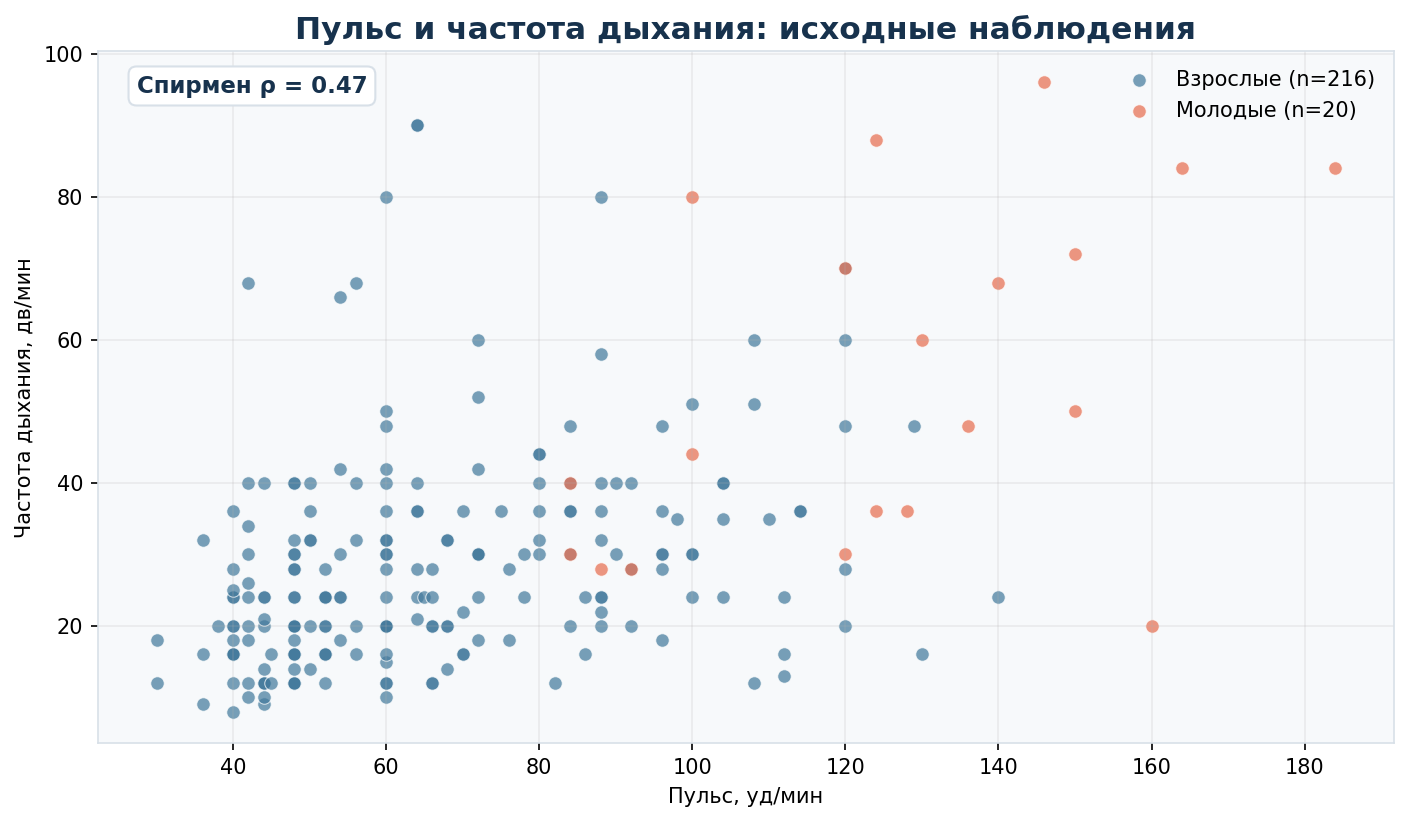

In [60]:
_corr_data = horse_data[['age', 'pulse', 'respiratory_rate']].dropna()
_age_colors = {1: '#457B9D', 2: '#E76F51'}
_age_labels = {1: 'Взрослые', 2: 'Молодые'}
_spearman = horse_data[['pulse', 'respiratory_rate']].corr(method='spearman').iloc[0, 1]

fig, ax = plt.subplots(figsize=(9.5, 5.6))
for _age in sorted(_corr_data['age'].unique()):
    _subset = _corr_data[_corr_data['age'] == _age]
    ax.scatter(
        _subset['pulse'],
        _subset['respiratory_rate'],
        s=42,
        alpha=0.72,
        color=_age_colors[_age],
        edgecolor='white',
        linewidth=0.5,
        label=f'{_age_labels[_age]} (n={len(_subset)})',
    )

ax.text(0.03, 0.94, f'Спирмен ρ = {_spearman:.2f}', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='#17324D',
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '#D8E0E8'})
ax.set_title('Пульс и частота дыхания: исходные наблюдения', fontsize=15, fontweight='bold', color='#17324D')
ax.set_xlabel('Пульс, уд/мин')
ax.set_ylabel('Частота дыхания, дв/мин')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
fig


In [61]:
# Заполняем пропуски в столбце respiratory_rate медианой, сгруппированной по столбцам pulse, age


fill_horse_data['respiratory_rate'] = fill_horse_data['respiratory_rate'].fillna(fill_horse_data.groupby(['pulse', 'age'])\
                                                                   ['respiratory_rate'].transform('median'))

print(fill_horse_data['respiratory_rate'].isna().sum())


'''
Совместная группировка по pulse и age позволяет учитывать как связь частоты дыхания с пульсом,
так и физиологические различия между взрослыми и молодыми лошадьми.
Поскольку некоторые сочетания пульса и возраста представлены недостаточным количеством наблюдений,
оставшиеся пропуски заполняются медианой по возрастной группе.'''


6


In [62]:
# Второй этап: оставшиеся пропуски в respiratory_rate заполняем  медианой по age

# резервную медиану мы считаем по исходным данным, не имеющим восстановленных значений

fill_horse_data['respiratory_rate'] = fill_horse_data['respiratory_rate'].fillna(horse_data.groupby('age')\
                                                                   ['respiratory_rate'].transform('median'))

print(fill_horse_data['respiratory_rate'].isna().sum())


0


In [63]:
(fill_horse_data.isna().mean() * 100).round(2)


surgery                       0.0
age                           0.0
rectal_temperature            0.0
pulse                         0.0
respiratory_rate              0.0
temperature_of_extremities    0.0
pain                          0.0
outcome                       0.0

In [64]:
# После заполнения категориальные признаки снова приводим к целочисленным кодам
_categorical_columns_final = [
    'surgery', 'age', 'temperature_of_extremities', 'pain', 'outcome'
]
fill_horse_data[_categorical_columns_final] = (
    fill_horse_data[_categorical_columns_final].astype('int64')
)

fill_horse_data.dtypes


surgery                         int64
age                             int64
rectal_temperature            float64
pulse                         float64
respiratory_rate              float64
temperature_of_extremities      int64
pain                            int64
outcome                         int64

## Итоговый аудит качества

Добавленные ниже проверки не меняют данные. Они фиксируют, какие методы были применены, и сравнивают состояние датафрейма до и после импутации.


In [65]:
_imputation_methods = {
    'surgery': 'Мода по pain',
    'age': 'Пропусков не было; валидация кодов',
    'rectal_temperature': 'Медиана по age',
    'pulse': 'Медиана по age + surgery',
    'respiratory_rate': 'Медиана по pulse + age; резерв по age',
    'temperature_of_extremities': 'Единственная мода по pulse; при ничьей/отсутствии — общая мода',
    'pain': 'Мода по surgery + outcome',
    'outcome': 'Мода по pain',
}

imputation_audit = pd.DataFrame({
    'Пропуски до': horse_data.isna().sum(),
    'Доля до, %': (horse_data.isna().mean() * 100).round(2),
    'Метод': pd.Series(_imputation_methods),
    'Пропуски после': fill_horse_data.isna().sum(),
})

imputation_audit


,Пропуски до,"Доля до, %",Метод,Пропуски после
surgery,1,0.33,Мода по pain,0
age,0,0.00,Пропусков не было; валидация кодов,0
rectal_temperature,60,20.00,Медиана по age,0
pulse,24,8.00,Медиана по age + surgery,0
respiratory_rate,58,19.33,Медиана по pulse + age; резерв по age,0
temperature_of_extremities,56,18.67,Единственная мода по pulse; при ничьей/отсутст...,0
pain,55,18.33,Мода по surgery + outcome,0
outcome,1,0.33,Мода по pain,0


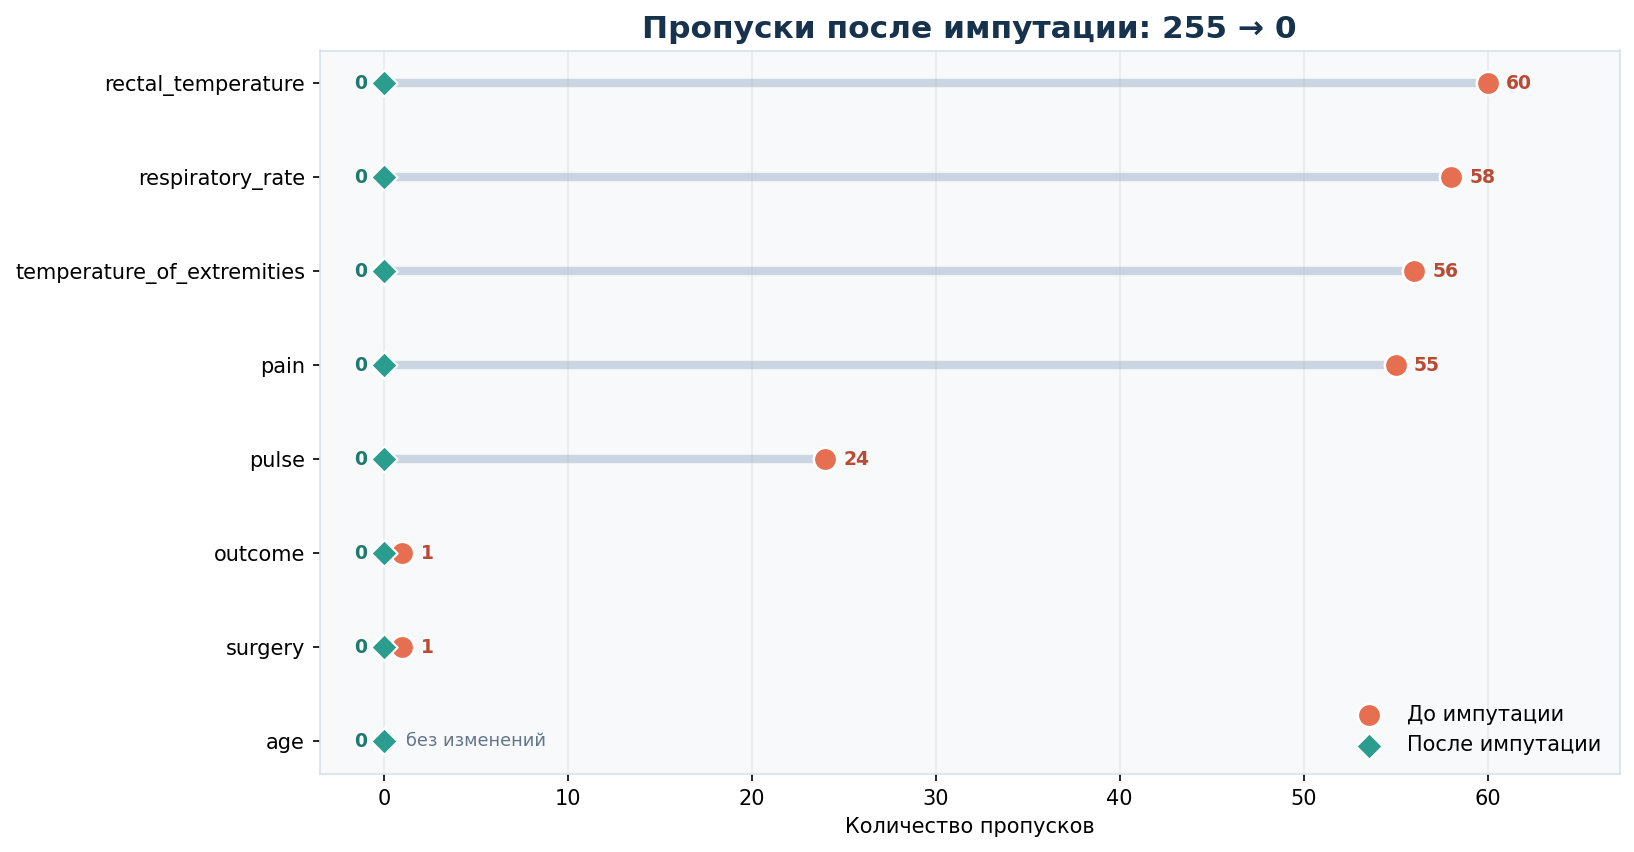

In [66]:
_before_missing = horse_data.isna().sum().sort_values()
_after_missing = fill_horse_data.isna().sum().reindex(_before_missing.index)
_positions = np.arange(len(_before_missing))

fig, ax = plt.subplots(figsize=(11, 5.8))

# Линия показывает путь от исходного числа пропусков к результату.
for position, before, after in zip(_positions, _before_missing.values, _after_missing.values):
    ax.plot([after, before], [position, position],
            color='#CBD5E1', linewidth=4, solid_capstyle='round', zorder=1)

# Разные форма и цвет делают обе точки различимыми даже при совпадении значений.
ax.scatter(_before_missing.values, _positions, s=125, marker='o',
           color='#E76F51', edgecolor='white', linewidth=1.2,
           label='До импутации', zorder=3)
ax.scatter(_after_missing.values, _positions, s=80, marker='D',
           color='#2A9D8F', edgecolor='white', linewidth=1.0,
           label='После импутации', zorder=4)

for position, before, after in zip(_positions, _before_missing.values, _after_missing.values):
    ax.text(after - 0.9, position, str(int(after)), ha='right', va='center',
            fontsize=9, fontweight='bold', color='#1F7A6D')
    if before == after:
        ax.text(before + 1.2, position, 'без изменений', ha='left', va='center',
                fontsize=8.5, color='#64748B')
    else:
        ax.text(before + 1.0, position, str(int(before)), ha='left', va='center',
                fontsize=9, fontweight='bold', color='#B94B35')

ax.set_yticks(_positions)
ax.set_yticklabels(_before_missing.index)
ax.set_xlabel('Количество пропусков')
ax.set_xlim(-3.5, max(_before_missing.max() * 1.12, 5))
ax.set_title('Пропуски после импутации: 255 → 0',
             fontsize=15, fontweight='bold', color='#17324D')
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
fig


### Влияние импутации на распределения

Наложение гистограмм показывает типичный эффект медианной импутации: часть наблюдений концентрируется вокруг групповых центров. Исходные зарегистрированные значения не изменяются.


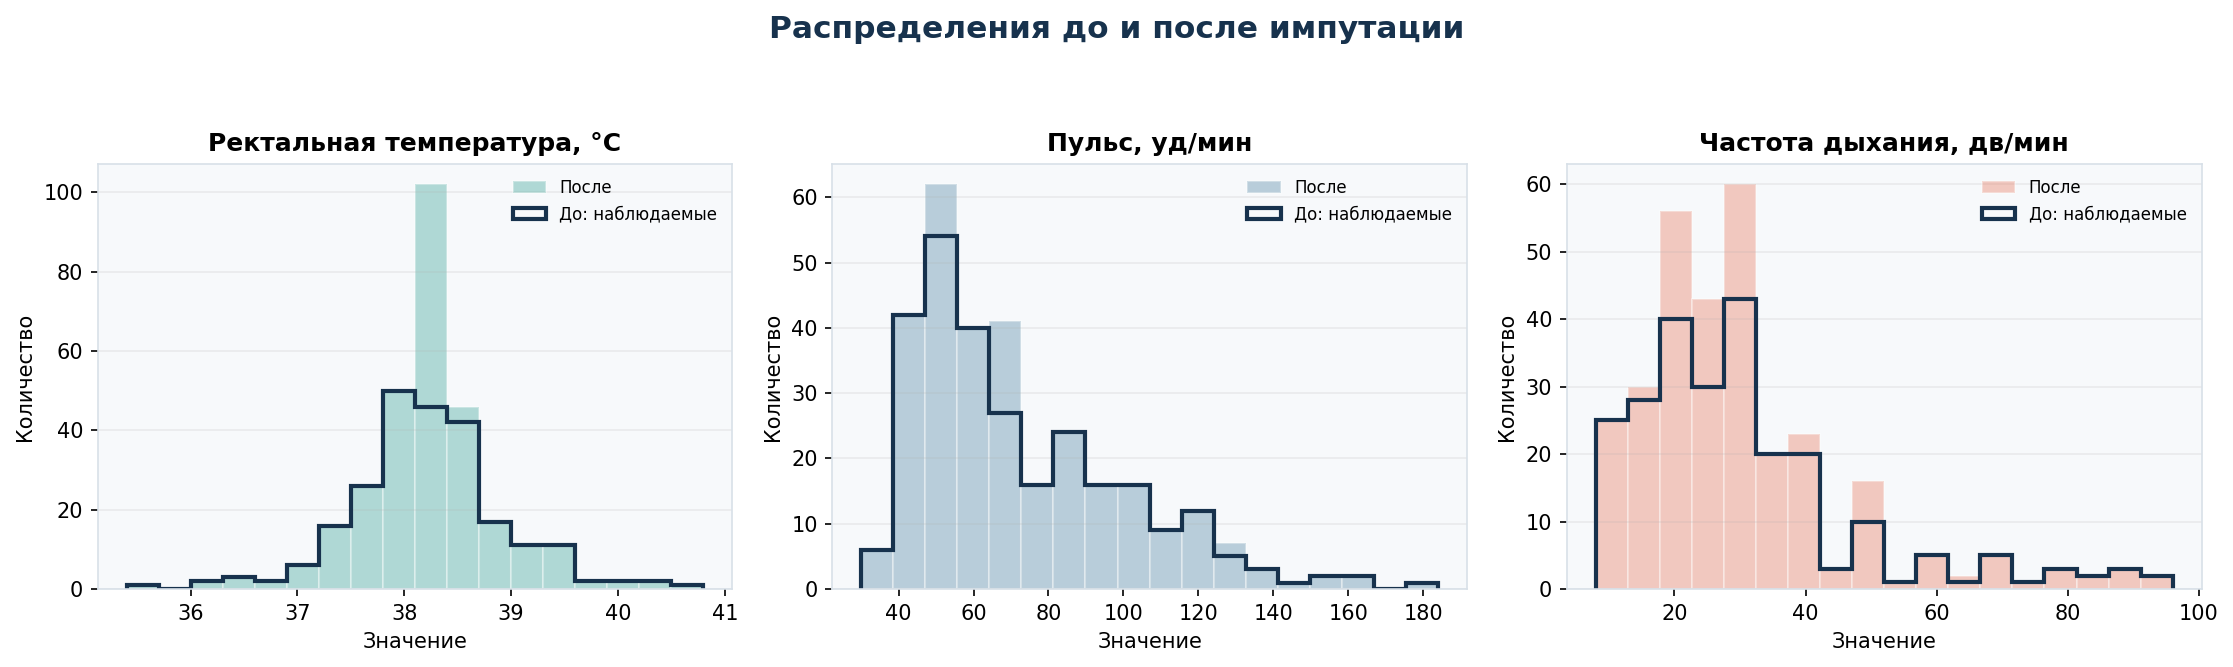

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, column, color in zip(axes, _viz_continuous_columns, _portfolio_colors):
    _observed = horse_data[column].dropna()
    _completed = fill_horse_data[column]
    _bins = np.linspace(min(_completed.min(), _observed.min()), max(_completed.max(), _observed.max()), 19)
    ax.hist(_completed, bins=_bins, color=color, alpha=0.35, label='После', edgecolor='white')
    ax.hist(_observed, bins=_bins, histtype='step', color='#17324D', linewidth=2, label='До: наблюдаемые')
    ax.set_title(_portfolio_labels[column])
    ax.set_xlabel('Значение')
    ax.set_ylabel('Количество')
    ax.legend(frameon=False, fontsize=8)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Распределения до и после импутации', fontsize=15, fontweight='bold', color='#17324D')
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig


In [68]:
_valid_categories = {
    'surgery': {1, 2},
    'age': {1, 2},
    'temperature_of_extremities': {1, 2, 3, 4},
    'pain': {1, 2, 3, 4, 5},
    'outcome': {1, 2, 3},
}

_category_checks = all(
    set(fill_horse_data[column].dropna().astype(int).unique()).issubset(allowed)
    for column, allowed in _valid_categories.items()
)

_integer_category_types = all(
    pd.api.types.is_integer_dtype(fill_horse_data[column])
    for column in _valid_categories
)

_observed_values_preserved = all(
    np.array_equal(
        fill_horse_data.loc[horse_data[column].notna(), column].to_numpy(dtype=float),
        horse_data.loc[horse_data[column].notna(), column].to_numpy(dtype=float),
    )
    for column in horse_data.columns
)

quality_checks = pd.Series({
    'Сохранено 300 строк': len(fill_horse_data) == len(horse_data) == 300,
    'Сохранено 8 признаков': fill_horse_data.shape[1] == 8,
    'Пропусков нет': fill_horse_data.isna().sum().sum() == 0,
    'Категориальные коды валидны': _category_checks,
    'Категориальные типы целочисленные': _integer_category_types,
    'Исходные наблюдаемые значения сохранены': _observed_values_preserved,
}, name='Пройдено')

quality_checks


Сохранено 300 строк                        True
Сохранено 8 признаков                      True
Пропусков нет                              True
Категориальные коды валидны                True
Категориальные типы целочисленные          True
Исходные наблюдаемые значения сохранены    True

In [69]:
_processed_path = Path('data/horse_data_imputed.csv')
fill_horse_data.to_csv(_processed_path, index=False)
print(f'Обработанные данные сохранены: {_processed_path}')


Обработанные данные сохранены: data/horse_data_imputed.csv


## Выводы

- В восьми выбранных признаках было **255 пропусков** — 10,6% всех ячеек анализируемой матрицы.
- До коррекции `age` содержал 276 значений `1` и 24 значения `9`; после явно обозначенного допущения `9 → 2` все коды пяти категориальных признаков соответствуют описанию.
- Полностью заполнены 154 исходные строки, а 69 строк содержат не менее двух пропусков; поэтому удаление неполных строк означало бы существенную потерю данных.
- Критерий IQR выделил **36 крайних значений в 33 строках**. Они сохранены, поскольку могут отражать реальные тяжёлые состояния, а не ошибки ввода.
- Для импутации использованы медианы и моды внутри содержательно выбранных групп, а для редких групп — простые резервные правила.
- При заполнении `temperature_of_extremities` обнаружено 10 групп пульса с несколькими модами; ничья затрагивала 8 пропущенных строк. В таких случаях не выбирался первый код, а применялась общая мода.
- Связь пульса и частоты дыхания умеренная и положительная: **Spearman ρ ≈ 0,47**.
- После обработки сохранены **все 300 наблюдений**, количество пропусков снижено до **0**, а категориальные столбцы приведены к целочисленному типу.

## Ограничения и границы применения

1. Замена `age: 9 → 2` — обоснованное, но всё же непроверяемое по первичной медицинской карте допущение.
2. Медианная и модальная импутация снижает естественную вариативность и может усиливать наиболее частые категории.
3. Использование `outcome` для заполнения `pain` допустимо в рамках описательной задачи, но станет **утечкой целевой переменной**, если задачей будет прогноз исхода.
4. Точные группы пульса иногда малы; поэтому для части строк применяются резервные правила. Размер групп-доноров не использовался как отдельный порог надёжности.
5. Числовые коды категорий служат метками: средние, дисперсии и арифметические расстояния между ними не интерпретируются.
6. Это учебно-аналитический проект, а не клиническая система поддержки решений.


**Итог:** в `fill_horse_data` больше нет пропусков.
